## Configuración Google Colab
> **Solo si estás en Colab:** ejecuta la siguiente celda para montar Google Drive.
> Si trabajas en local (VS Code / Jupyter), puedes saltártela.

In [41]:
import sys
import matplotlib.pyplot as plt
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    import os
    # Change 'archive' to the folder name you uploaded to Drive
    RUTA_DRIVE = '/content/drive/MyDrive/archive'
    os.chdir(RUTA_DRIVE)
    print(f"Directorio: {os.getcwd()}")
    # Install dependencies
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'seaborn', 'scipy'])
else:
    import os
    print(f"Entorno local — directorio: {os.getcwd()}")
import os
"""
# ── Output folder for visualizations ────────────────────
VIZ_DIR = '/content/drive/MyDrive/archive/charts'
os.makedirs(VIZ_DIR, exist_ok=True)  # creates it if it does not exist

def save_and_show(filename):
    ruta = os.path.join(VIZ_DIR, filename)
    plt.savefig(ruta, bbox_inches='tight')
    plt.close()
    display(Image(ruta))"""

Entorno local — directorio: /home/josema/Proyectos/Bootcamp_IA/Proyectos/Proyecto4/HRIA/HRIA/notebooks


"\n# ── Output folder for visualizations ────────────────────\nVIZ_DIR = '/content/drive/MyDrive/archive/charts'\nos.makedirs(VIZ_DIR, exist_ok=True)  # creates it if it does not exist\n\ndef save_and_show(filename):\n    ruta = os.path.join(VIZ_DIR, filename)\n    plt.savefig(ruta, bbox_inches='tight')\n    plt.close()\n    display(Image(ruta))"

In [42]:
#1. Dynamically locate the project root directory
base_dir = os.path.abspath(os.getcwd())
if os.path.basename(base_dir) == 'notebooks':
    base_dir = os.path.dirname(base_dir)

# 2. Update the output folder for visualizations to the new local structure
VIZ_DIR = os.path.join(base_dir, 'charts')
os.makedirs(VIZ_DIR, exist_ok=True)  # Creates the directory if it does not exist

# 3. Updated function with dynamic path routing and English variable names
def save_and_show(filename):
    """
    Saves the current matplotlib figure into the charts/ directory and displays it.
    """
    file_path = os.path.join(VIZ_DIR, filename)
    plt.savefig(file_path, bbox_inches='tight')
    plt.close()
    display(Image(file_path))
    print(f"Chart saved: {os.path.relpath(file_path, base_dir)}")

## 1. Setup e importación

In [43]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import ast
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Patch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.ticker import PercentFormatter
matplotlib.use('Agg')   # headless backend, compatible with Jupyter and servers
import shutil
#shutil.copy('/content/drive/MyDrive/archive/Logo.png', '/content/Logo.png')
import warnings
warnings.filterwarnings('ignore')

from IPython.display import Image, display

# Visual style
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

PROCESSED = "../data/processed/"

# Load clean data
df     = pd.read_csv(PROCESSED + "data_roles_completo.csv", low_memory=False)
df_sal = pd.read_csv(PROCESSED + "data_roles_salario.csv",  low_memory=False)

print(f"Dataset completo:  {df.shape}")
print(f"Dataset salarial:  {df_sal.shape}")

Dataset completo:  (2916, 39)
Dataset salarial:  (882, 39)



# EDA Proyecto I — Fase 4: Visualización
**HRIA - DataTalent Solutions S.L.** | Módulo II: Análisis y Visualización de Datos

> ## ⚠️ Advertencia de sesgo geográfico
>
>El dataset analizado proviene de **LinkedIn Job Postings (USA, 2023–2024)**.
> La distribución geográfica está fuertemente sesgada hacia el mercado estadounidense.
>
> **Implicaciones directas para este análisis:**
> - Los salarios reflejan estándares USA
> - Las industrias líderes (IT Services, Financial Services) tienen un peso diferente en España
> - Las skills demandadas pueden diferir: el mercado español tiene mayor presencia de banca,
>   sector público y turismo
>
> **Conclusión:** los hallazgos de este análisis son válidos como **referencia de tendencias
> globales**, pero no deben usarse directamente para orientación salarial en España sin
> cruzarlos con fuentes locales (Infojobs, Tecnoempleo, SEPE).
---

## Visualización Introducción — Sesgos Críticos: MNAR + Geográfico

Antes de tomar decisiones basadas en este análisis, DataTalent debe
entender qué parte del mercado estamos viendo realmente. Esta
visualización combina los dos sesgos más críticos del dataset.




## Interpretación

**Gráfico izquierdo — Sesgo MNAR:**
Solo el 31% de las ofertas publica salario voluntariamente. No es
aleatório — las empresas que publican salario tienden a ser más
grandes y pagar mejor. Todo el análisis salarial de este EDA
se basa en ese 31%.

**Gráfico derecho — Sesgo Geográfico:**
De las ofertas con país identificado, la gran mayoría provienen
de USA. España está subrepresentada o directamente ausente,
lo que significa que las cifras salariales y la demanda de
skills reflejan el mercado estadounidense, no el español.

**Conclusión combinada para DataTalent:**

> *Estamos analizando el 31% del mercado, y ese 31% es
> mayoritariamente USA. Las tendencias son válidas como
> referencia global, pero cualquier decisión comercial
> para el mercado español debe contrastarse con fuentes locales.*



---
## Visualización 1 — Distribución del Salario Anual
**Tipo:** Histograma + KDE + Curva Normal teórica.

**Propósito:** Verificar si los salarios en roles de datos siguen una distribución aproximadamente normal y mostrar la asimetría de la distribución real.

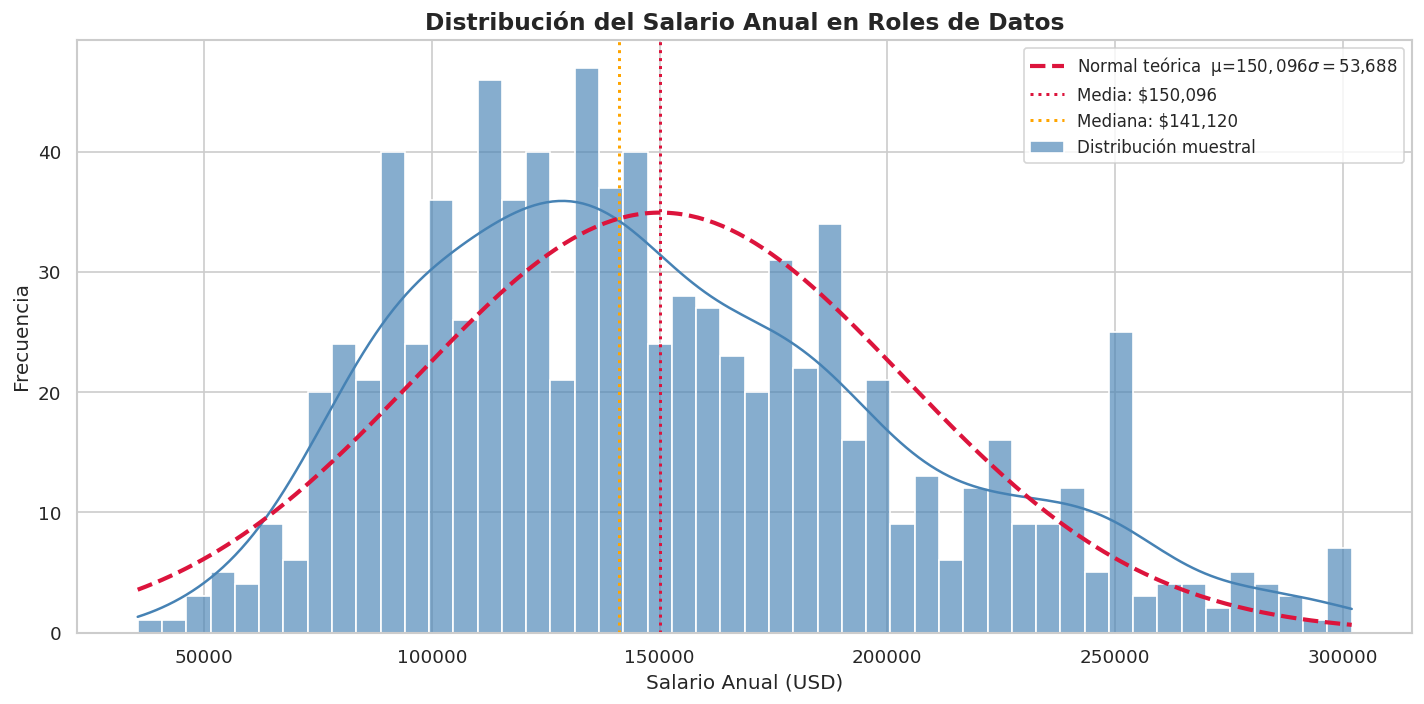

Chart saved: charts/viz1_distribucion_salario.png
Guardado: viz1_distribucion_salario.png


In [44]:
fig, ax = plt.subplots(figsize=(12, 6))

data_sal = df_sal['salary_annual'].dropna()

# Histogram with real KDE
sns.histplot(data_sal, bins=50, kde=True, color='steelblue',
             alpha=0.65, label='Distribución muestral', ax=ax)

# Theoretical Normal curve overlay
mu, sigma  = data_sal.mean(), data_sal.std()
x          = np.linspace(data_sal.min(), data_sal.max(), 300)
bin_width  = (data_sal.max() - data_sal.min()) / 50
y_normal   = stats.norm.pdf(x, mu, sigma) * len(data_sal) * bin_width

ax.plot(x, y_normal, color='crimson', linewidth=2.5, linestyle='--',
        label=f'Normal teórica  \u03bc=${mu:,.0f}  \u03c3=${sigma:,.0f}')

# Reference lines
ax.axvline(mu,                color='crimson', linestyle=':', linewidth=1.8,
           label=f'Media: ${mu:,.0f}')
ax.axvline(data_sal.median(), color='orange',  linestyle=':', linewidth=1.8,
           label=f'Mediana: ${data_sal.median():,.0f}')

ax.set_title('Distribución del Salario Anual en Roles de Datos', fontsize=14, fontweight='bold')
ax.set_xlabel('Salario Anual (USD)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
save_and_show('viz1_distribucion_salario.png')
print("Guardado: viz1_distribucion_salario.png")

## Interpretación

La distribución real presenta asimetría positiva (cola derecha): la mayoría de los roles
se concentran entre \$80k–\$200k, pero un segmento reducido de posiciones directivas
en grandes tecnológicas eleva la media hasta \$150,000;
por encima de la mediana
\$141,124. La curva normal teórica sobreestima la frecuencia de salarios extremos —
confirmando que la distribución real no es normal.

En simples palabras**: Unos pocos salarios muy altos tiran de la media hacia arriba, haciendo que parezca que el mercado paga más de lo que realmente paga la mayoría.

**Implicación para DataTalent:** usar la media como referencia salarial en la propuesta
comercial inflaría las expectativas de los candidatos. La mediana es mejor indicador.

**Limitación crítica:** el 69% de las ofertas no publica salario. Estos datos
representan solo el 29% del mercado, sesgado hacia empresas grandes que pagan mejor.
El salario real del mercado probablemente es más bajo.

## 1.1. Distribución Normal vs. Lognormal

**Tipo**: Gráficos Q-Q (Normal vs. Lognormal) en escala real.

**Propósito**: Validar visualmente la bondad de ajuste de los salarios a una distribución logarítmica, evidenciando que la asimetría y el comportamiento de las colas (sueldos altos) se modelan mejor con una curva Lognormal que con una Normal.

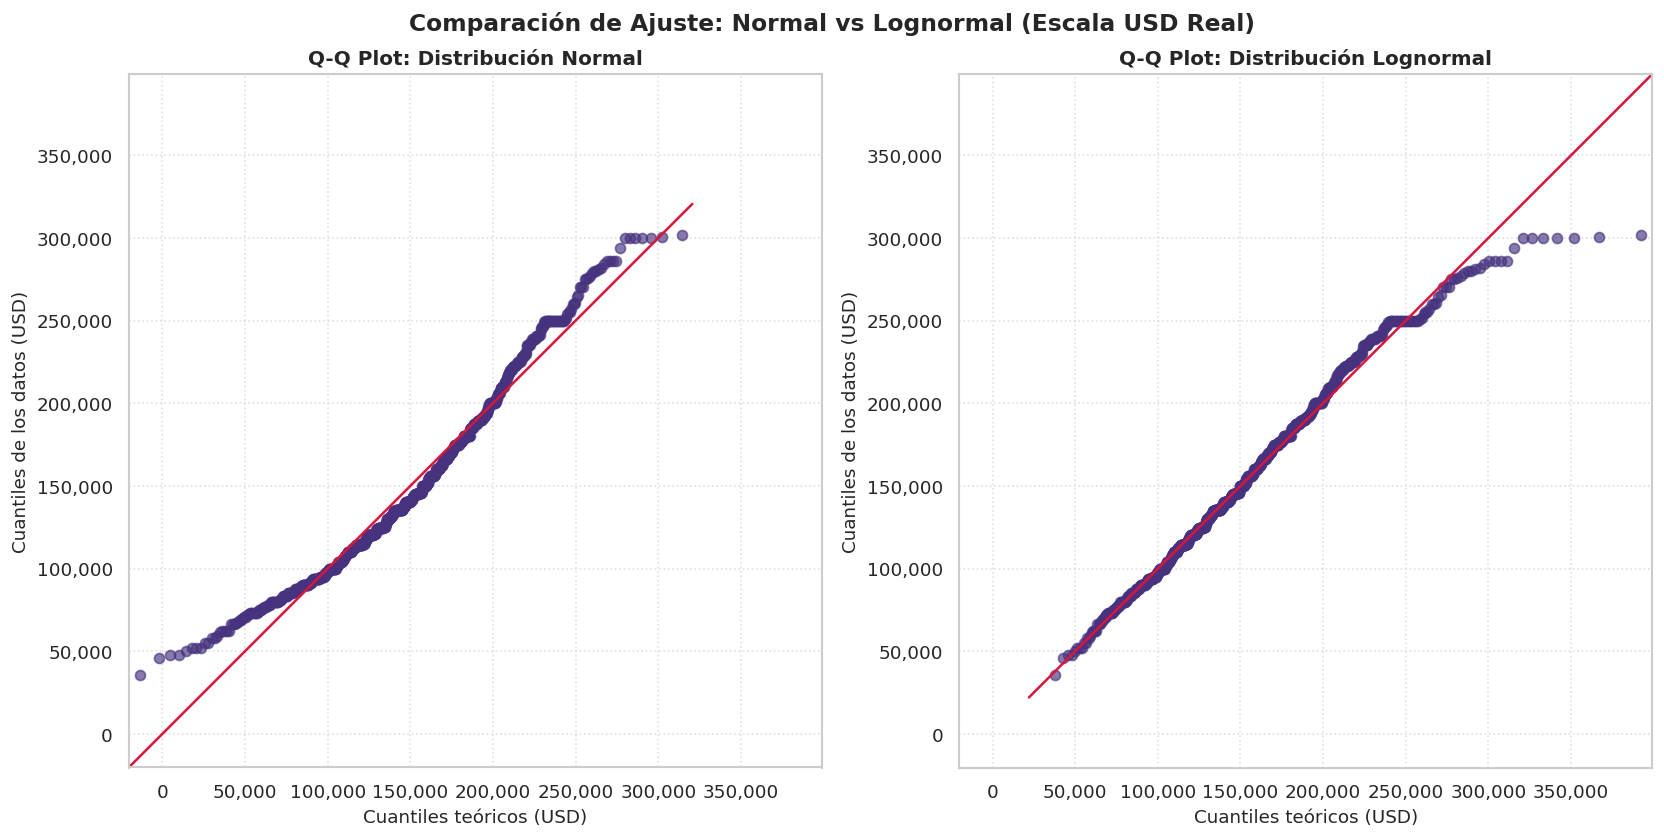

Chart saved: charts/viz1.2_qq_plots_escala_real.png
Guardado: viz1.2_qq_plots_escala_real.png


In [45]:
import scipy.stats as stats
import statsmodels.api as sm

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Q-Q Plot: Normal distribution
mu, sigma = data_sal.mean(), data_sal.std()

# Generate the Q-Q plot passing the local sample parameters
sm.qqplot(
    data_sal,
    dist=stats.norm,
    loc=mu,
    scale=sigma,
    line="45",
    ax=axes[0],
)

# Custom styling
axes[0].get_lines()[0].set_color("steelblue")
axes[0].get_lines()[0].set_alpha(0.65)
axes[0].get_lines()[1].set_color("crimson")
axes[0].set_title(
    "Q-Q Plot: Distribución Normal",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_xlabel("Cuantiles teóricos (USD)", fontsize=11)
axes[0].set_ylabel("Cuantiles de los datos (USD)", fontsize=11)

# Q-Q Plot: Lognormal distribution
shape, loc, scale = stats.lognorm.fit(data_sal)

# Generate the Q-Q plot using the fitted lognormal parameters
sm.qqplot(
    data_sal,
    dist=stats.lognorm,
    distargs=(shape,),
    loc=loc,
    scale=scale,
    line="45",
    ax=axes[1],
)

# Custom styling
axes[1].get_lines()[0].set_color("steelblue")
axes[1].get_lines()[0].set_alpha(0.65)
axes[1].get_lines()[1].set_color("crimson")
axes[1].set_title(
    "Q-Q Plot: Distribución Lognormal",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel("Cuantiles teóricos (USD)", fontsize=11)
axes[1].set_ylabel("Cuantiles de los datos (USD)", fontsize=11)

# Axis Equalization & Alignment (1:1 Aspect Ratio and Uniform Scale)
all_min = min(axes[0].get_xlim()[0], axes[1].get_xlim()[0])
all_max = max(axes[0].get_xlim()[1], axes[1].get_xlim()[1])

for ax in axes:
    ax.grid(True, linestyle=":", alpha=0.6)

    # Force a perfect square aspect ratio
    ax.set_aspect("equal", adjustable="box")

    # Apply the same unified global range to both X and Y axes
    ax.set_xlim(all_min, all_max)
    ax.set_ylim(all_min, all_max)

    # Format axis tick labels with thousands separators for better readability
    ax.xaxis.set_major_formatter("{x:,.0f}")
    ax.yaxis.set_major_formatter("{x:,.0f}")

# Overall figure layout settings
plt.suptitle(
    "Comparación de Ajuste: Normal vs Lognormal (Escala USD Real)",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()

save_and_show("viz1.2_qq_plots_escala_real.png")
print("Guardado: viz1.2_qq_plots_escala_real.png")

## Interpretación

1. **Q-Q Plot: Distribución Normal** (*izquierda*)

Este gráfico muestra de forma evidente por qué los salarios del dataset no son normales:

- Desviación en las colas (Extremos): En la cola inferior (salarios bajos, cerca de 0) y en la cola superior (salarios altos, por encima de 200,000\$), los puntos azules se separan drásticamente de la línea roja de referencia.

- Forma de "S" invertida: Esta curvatura indica que la distribución real de los datos tiene un sesgo a la derecha (asimetría positiva). Hay una acumulación fuerte de profesionales ganando salarios bajos y medios, y una cola larga de salarios altos que la distribución Normal teórica es incapaz de modelar correctamente.

2. **Q-Q Plot: Distribución Lognormal** (*derecha*)

Aquí es donde el ajuste se vuelve notablemente superior:

- Trayectoria casi perfecta: En el cuerpo central de los datos (aproximadamente entre los 50,000\$ y los 250,000\$). Esto significa que en el rango donde se encuentra la gran mayoría de los profesionales de datos, la distribución lognormal describe el comportamiento a la perfección.

- El aplanamiento al final (Por encima de 280,000\$): Al final los puntos se vuelven horizontales. Esto revela que hay un techo o límite salarial (el salario máximo ronda los 280,000\$). La distribución lognormal supone que la cola derecha podría extenderse de forma indefinida (hacia los 400,000\$ o más), pero en tu muestra real los salarios máximos se estabilizan ahí.

---
## Visualización 2 — Salario por Nivel de Experiencia (Boxplot)
**Tipo:** Diagrama de caja (boxplot)
**Propósito:** Comparar la distribución salarial entre niveles de experiencia y detectar outliers por nivel.

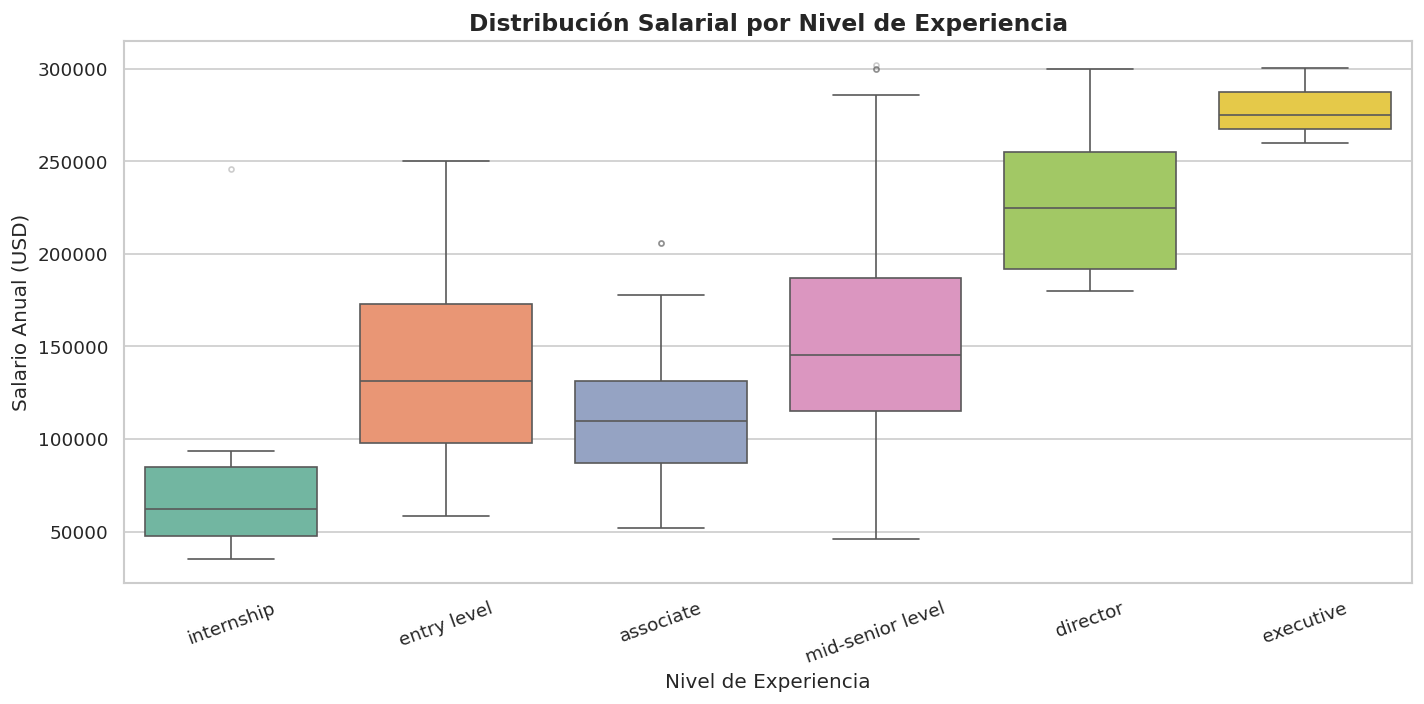

Chart saved: charts/viz2_boxplot_experiencia.png
Guardado: viz2_boxplot_experiencia.png


In [46]:
fig, ax = plt.subplots(figsize=(12, 6))

orden = ['internship','entry level','associate','mid-senior level','director','executive']
df_box = df_sal[df_sal['formatted_experience_level'].isin(orden)].copy()
orden_present = [o for o in orden if o in df_box['formatted_experience_level'].unique()]

sns.boxplot(
    data=df_box,
    x='formatted_experience_level',
    y='salary_annual',
    order=orden_present,
    palette='Set2',
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3},
    ax=ax
)

ax.set_title('Distribución Salarial por Nivel de Experiencia', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de Experiencia', fontsize=12)
ax.set_ylabel('Salario Anual (USD)', fontsize=12)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
save_and_show('viz2_boxplot_experiencia.png')
print("Guardado: viz2_boxplot_experiencia.png")

## Interpretación

La escalera salarial es estadísticamente clara: Director y Executive tienen medianas
~2x superiores a Entry Level. Sin embargo, dos hallazgos merecen atención:

1. La caja de Executive es la más amplia: dos directivos pueden cobrar
   cantidades radicalmente distintas según industria y empresa.
2. Internship tiene outliers en $240k — probablemente prácticas remuneradas en FAANG,
   no representativas del mercado general.

**Implicación:** el reskilling de Entry a Mid-Senior es el salto con mayor ROI ajustado
al riesgo. El salto a Director implica mayor variabilidad: el resultado depende más del
contexto que de las habilidades.

## Visualización 3 — Comparativa de ofertas por área de negocio: Mercado Global vs España
**Tipo:** Gráfico de barras horizontales doble
**Propósito:** Contrastar qué áreas de negocio son las que más demandadan roles de data a nivel global con
las del mercado español, identificando si el programa de reskilling de
DataTalent requiere adaptación curricular para el mercado local.

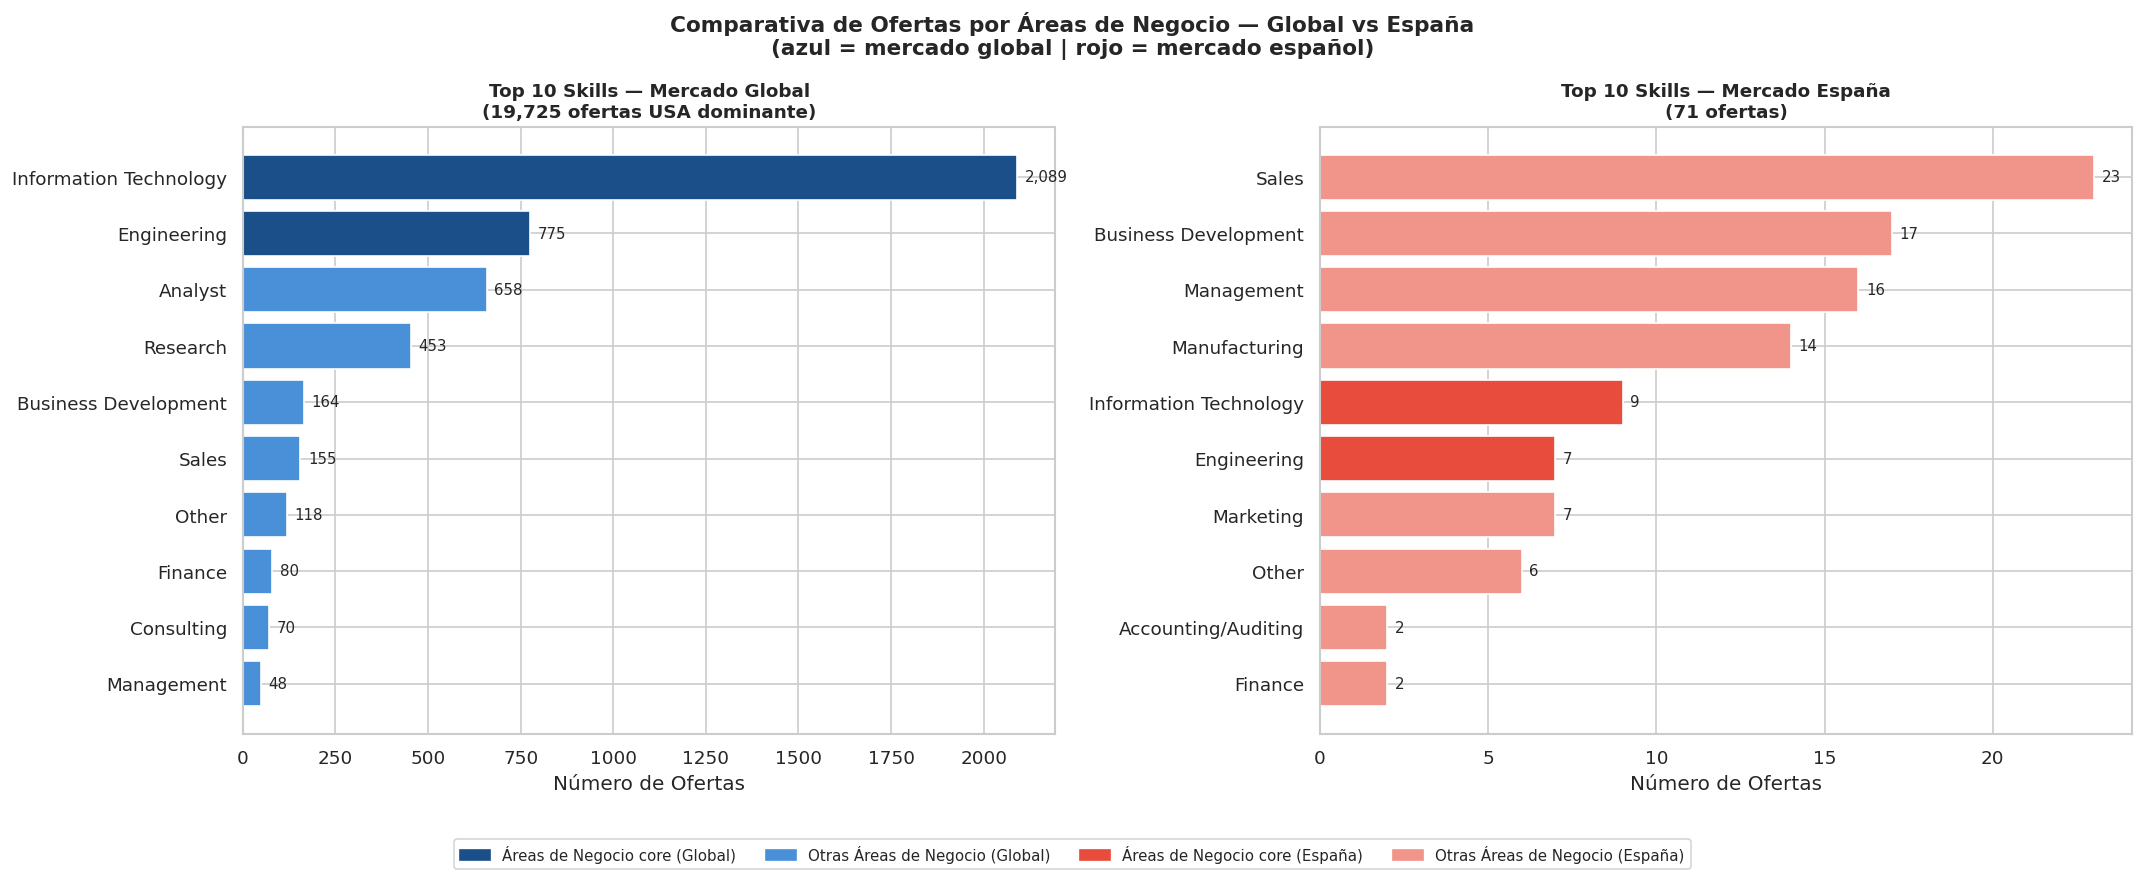

Chart saved: charts/viz3_business_units_global_vs_spain.png


In [47]:
# Viz 3 — Skills Comparison: Global vs Spain
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left panel: Global skills ─────────────────────
ax1 = axes[0]

if 'job_skills_list' in df.columns:
    df_sk = df[['job_id','job_skills_list']].dropna(subset=['job_skills_list']).copy()
    df_sk['skill'] = df_sk['job_skills_list'].str.split(', ')
    df_sk_e = df_sk.explode('skill')
    sk_global = df_sk_e['skill'].value_counts().head(10)

    colores_global = ['#1B4F8A' if s in ['Information Technology','Engineering']
                      else '#4A90D9' for s in sk_global.index[::-1]]

    bars1 = ax1.barh(sk_global.index[::-1], sk_global.values[::-1],
                     color=colores_global, edgecolor='white')

    for bar, val in zip(bars1, sk_global.values[::-1]):
        ax1.text(bar.get_width() + sk_global.max() * 0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

ax1.set_title('Top 10 Skills — Mercado Global\n(19,725 ofertas USA dominante)',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Número de Ofertas')

# ── Right panel: Spain skills ──────────────────────────────────
ax2 = axes[1]

# Load clean data
dm     = pd.read_csv(PROCESSED + "data_maestro_completo.csv", low_memory=False)

es = dm[dm['comp_country'] == 'ES'].copy()

if 'job_skills_list' in es.columns:
    es_sk = es[['job_id','job_skills_list']].dropna(subset=['job_skills_list']).copy()
    es_sk['skill'] = es_sk['job_skills_list'].str.split(', ')
    es_sk_e = es_sk.explode('skill')
    sk_spain = es_sk_e['skill'].str.strip().value_counts().head(10)

    colores_spain = ['#e74c3c' if s in ['Information Technology','Engineering']
                     else '#f1948a' for s in sk_spain.index[::-1]]

    bars2 = ax2.barh(sk_spain.index[::-1], sk_spain.values[::-1],
                     color=colores_spain, edgecolor='white')

    for bar, val in zip(bars2, sk_spain.values[::-1]):
        ax2.text(bar.get_width() + sk_spain.max() * 0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

ax2.set_title(f'Top 10 Skills — Mercado España\n({len(es)} ofertas)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Número de Ofertas')

# ── Legend ───────────────────────────────────────────────────────
from matplotlib.patches import Patch
leyenda = [
    Patch(color='#1B4F8A', label='Áreas de Negocio core (Global)'),
    Patch(color='#4A90D9', label='Otras Áreas de Negocio (Global)'),
    Patch(color='#e74c3c', label='Áreas de Negocio core (España)'),
    Patch(color='#f1948a', label='Otras Áreas de Negocio (España)'),
]
fig.legend(handles=leyenda, loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Comparativa de Ofertas por Áreas de Negocio — Global vs España\n'
             '(azul = mercado global | rojo = mercado español)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
save_and_show('viz3_business_units_global_vs_spain.png')

## Interpretación

El gráfico revela una diferencia estructural entre ambos mercados:

**Mercado Global (azul):**
Information Technology y Engineering dominan con enorme ventaja —
el mercado global busca ante todo perfiles técnicos puros.
Management, Finance y Sales aparecen como skills complementarias
pero claramente secundarias.

**Mercado España (rojo):**
El perfil se invierte. Sales, Business Development y Management
lideran — España busca perfiles comerciales y de gestión que
además entiendan los datos. Information Technology y Engineering
aparecen pero en quinta y sexta posición, con números muy bajos.
Marketing aparece en España y no en el top global.

**Lo que esto significa para DataTalent:**

> El candidato ideal para el mercado español no es un técnico puro
> que aprende a comunicarse — es un perfil comercial o de gestión
> que aprende Python y SQL para potenciar lo que ya sabe hacer.

Esto justifica un **programa de reskilling específico para España**
diferente al currícculo global, con mayor peso en:
- Análisis de datos aplicado a ventas y negocio
- Visualización orientada a decisiones comerciales
- Python y SQL como herramientas, no como fin en sí mismas

> ⚠️ **Limitación:** España tiene solo 71 ofertas totales (8 de roles
> de datos específicamente) frente a 19,725 globales. Las tendencias
> españolas son orientativas — contrastar con Infojobs o Tecnoempleo
> antes de tomar decisiones curriculares definitivas.


## Visualización 4. — Skills Técnicas


### Visualización 4.1 — Comparativa de skills más demandadas: Mercado Global vs España


**Tipo:** Gráfico de barras horizontales con resaltado por categoría.
**Propósito:** Resolver la limitación de la Viz 4.1[link text](https:// [link text](https://)). El dataset de LinkedIn solo tiene
8 ofertas de datos de España y sus "skills" son **categorías funcionales** (IT, Sales…),
no enseñables. Esta visualización usa **OrientaHub (Fundación Telefónica)** — el mercado
español real (InfoJobs + Tecnoempleo + TicJob + Buscojobs, Dic 2025–Abr 2026) — para
identificar las **tecnologías concretas** que debe contener el currículo de DataTalent.

> Es la fuente local que la propia Viz 3 recomendaba para contrastar antes de decidir el temario.

In [48]:
# Convert the string representation of a list into an actual Python list object
df_sal['hard_skills'] = df_sal['hard_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

# Expand the list of skills so that each skill occupies its own row
exploded_df_sal = df_sal.explode('hard_skills')

In [49]:
# Viz 4.1 — Real Technical Skills in the Spanish Market (OrientaHub)
# Fuente: OrientaHub / Fundación Telefónica · Dic 2025–Abr 2026

# El CSV puede estar en Drive (junto al resto del proyecto) o subirse a mano.
RAW = "../data/raw/"
spain_skills_path = os.path.join(RAW, 'skills_spain.csv')

# Check if the file exists before reading it to prevent crashes
if not os.path.exists(spain_skills_path):
    print("=" * 70)
    print(f"CRITICAL ERROR: File not found at: {spain_skills_path}")
    print("Please make sure to place the 'skills_spain.csv' file inside your 'data/raw/' folder.")
    print("Source: OrientaHub / Fundación Telefónica · Dec 2025–Apr 2026")
    print("=" * 70)
else:
    # Load the Spanish market technical skills dataset directly from RAW folder
    es_skills = pd.read_csv(spain_skills_path)
    
    # Handle column names safely (checks if column is named 'menciones' or 'mentions')
    mention_col = 'menciones' if 'menciones' in es_skills.columns else 'mentions'
    
    # Sort by mentions in descending order
    es_skills = es_skills.sort_values(mention_col, ascending=False).reset_index(drop=True)
    print(f"Spanish technical skills dataset successfully loaded | Shape: {es_skills.shape}")

Spanish technical skills dataset successfully loaded | Shape: (25, 3)


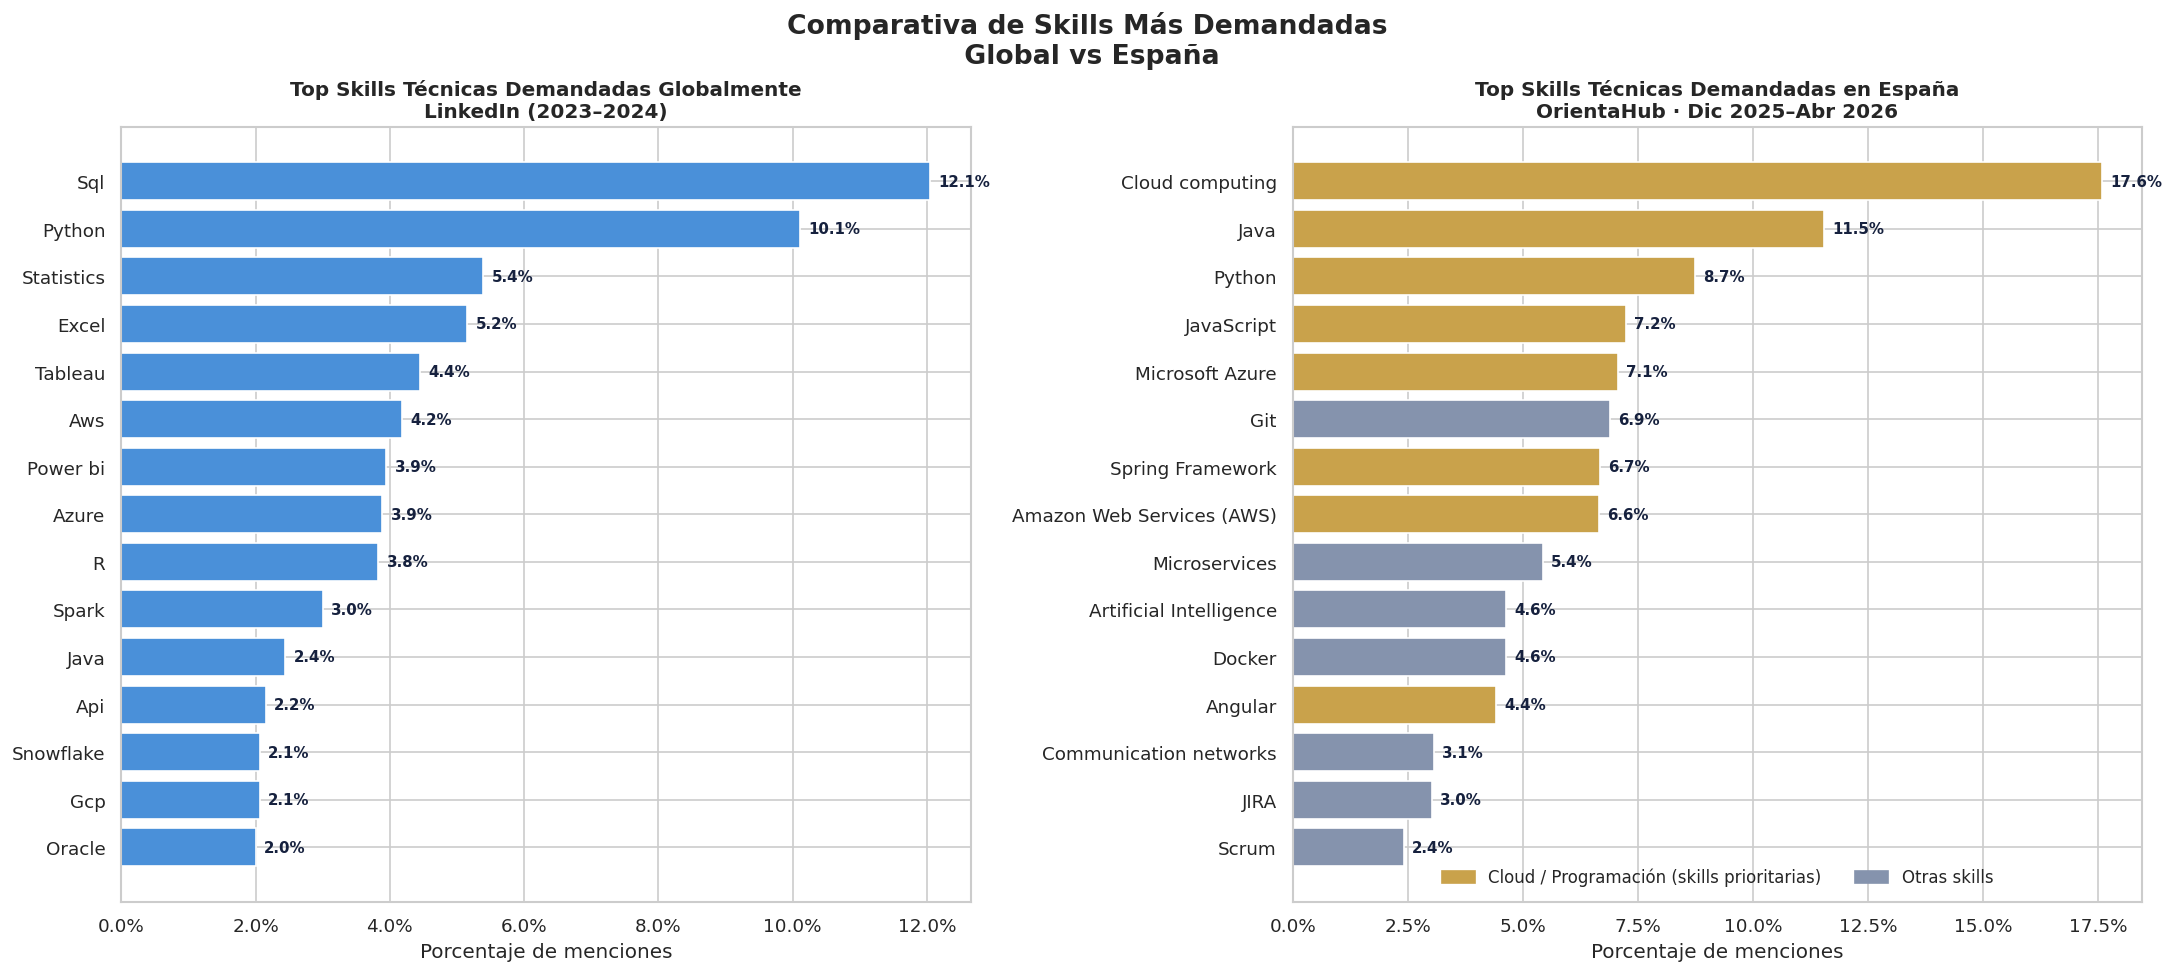

Chart saved: charts/viz4.1_hard_skills_global_vs_spain.png


In [50]:
# Top 15 skills as percentage of total mentions

TOP = 15

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(18, 8),
    constrained_layout=True
)

# Global skills subplot

skill_pct = (
    exploded_df_sal['hard_skills']
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
    .head(TOP)
    .sort_values(ascending=True)
)

skill_pct.index = skill_pct.index.str.capitalize()

bars1 = ax1.barh(
    skill_pct.index,
    skill_pct.values,
    color='#4A90D9',
    edgecolor='white'
)

for bar, val in zip(bars1, skill_pct.values):
    ax1.text(
        bar.get_width() + skill_pct.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='#16213E'
    )

ax1.set_title(
    'Top Skills Técnicas Demandadas Globalmente\n'
    'LinkedIn (2023–2024)',
    fontsize=12,
    fontweight='bold'
)

ax1.set_xlabel('Porcentaje de menciones')
ax1.xaxis.set_major_formatter(PercentFormatter())

# Spain skills subplot

d = es_skills.head(TOP).iloc[::-1].copy()

d['pct'] = d['menciones'] / d['menciones'].sum() * 100

colors_es = [
    '#C9A24B' if c in ('Cloud', 'Programming')
    else '#8593AD'
    for c in d['categoria']
]

bars2 = ax2.barh(
    d['skill'],
    d['pct'],
    color=colors_es,
    edgecolor='white'
)

for bar, val in zip(bars2, d['pct']):
    ax2.text(
        bar.get_width() + d['pct'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='#16213E'
    )

ax2.set_title(
    'Top Skills Técnicas Demandadas en España\n'
    'OrientaHub · Dic 2025–Abr 2026',
    fontsize=12,
    fontweight='bold'
)

ax2.set_xlabel('Porcentaje de menciones')
ax2.xaxis.set_major_formatter(PercentFormatter())

legend = [
    Patch(color='#C9A24B', label='Cloud / Programación (skills prioritarias)'),
    Patch(color='#8593AD', label='Otras skills')
]

ax2.legend(
    handles=legend,
    loc='lower center',
    ncol=2,
    frameon=False,
    fontsize=10
)

fig.suptitle(
    'Comparativa de Skills Más Demandadas\n Global vs España',
    fontsize=16,
    fontweight='bold'
)

save_and_show('viz4.1_hard_skills_global_vs_spain.png')

## Interpretación

El ranking revela una jerarquía clara de prioridades en el mercado español:

**El núcleo es Cloud (dorado):**
*Cloud computing* lidera con enorme ventaja (7.633 menciones), casi un 50% por encima del
segundo puesto. Sumado a *Microsoft Azure*, *AWS* y *Google Cloud Platform*, la nube es la
competencia transversal más demandada. El programa no puede ser solo de análisis de datos:
necesita un módulo cloud sólido.

**El lenguaje base, indispensable:**
*Java* (5.013) y *Python* (3.794) ocupan el segundo y tercer lugar. Cualquier itinerario debe
asentarse sobre un lenguaje troncal — Python para la vía de datos, Java para entornos empresariales.

**La huella de Data Engineer / DevOps:**
*Git*, *Docker*, *Microservices*, *Kubernetes* y *Terraform* aparecen con fuerza. El mercado
español tira hacia perfiles de ingeniería de datos, confirmando la ruta de evolución
Analyst → Engineer del análisis principal.

**En simples palabras:** España no contrata "saber de datos" en abstracto; contrata tecnologías
concretas. Y esas tecnologías se pueden enseñar.

**Implicación para DataTalent:** el currículo se deriva directamente de este gráfico —
**Cloud + un lenguaje base como Python + Git + metodología ágil**, con una capa diferencial
de negocio. Es un temario defendible porque nace de la demanda real, no de una intuición.

**Coherencia con el EDA:** esta visualización cierra la limitación que confesaba la Viz 3
(solo 8 ofertas de España, skills como categorías genéricas) y el sesgo nº6 del informe
(*"agregación de skills → currículo demasiado genérico"*). El dato USA daba la dirección
estratégica; la fuente española aporta el contenido concreto.

### Visualización 4.2 — Skills más demandadas según rol


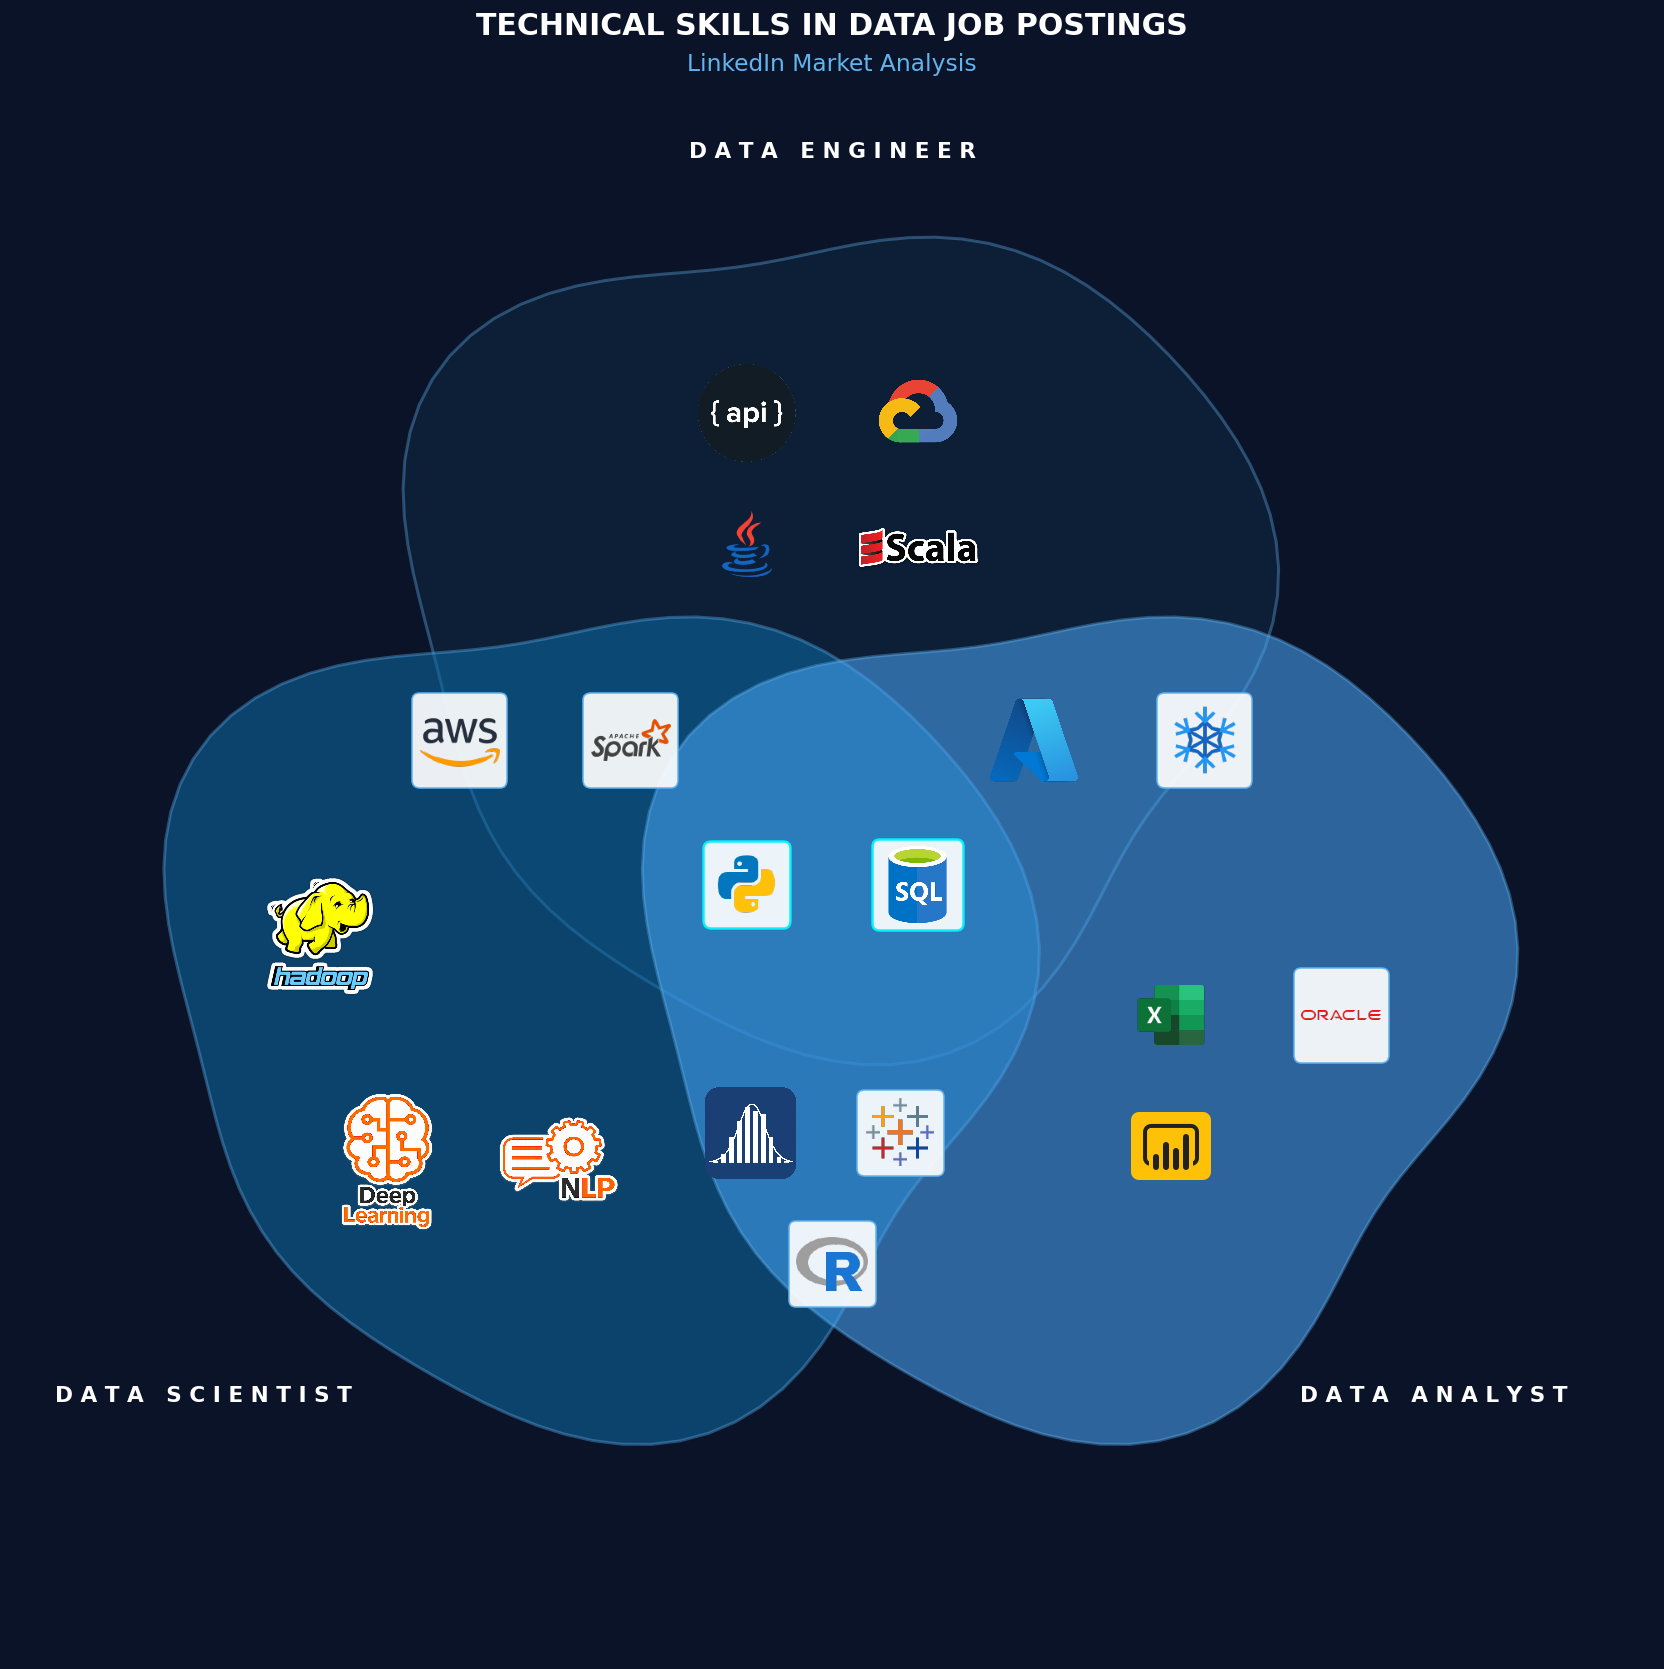

Chart saved: charts/viz4.2_most_demanded_skills_per_role.png


In [64]:
# 1. Define skill datasets
engineer_skills = {'python', 'sql', 'aws', 'azure', 'spark', 'java', 'scala',
                   'api', 'gcp', 'snowflake'}
scientist_skills = {'python', 'statistics', 'sql', 'r', 'nlp', 'aws', 'tableau',
                    'spark', 'hadoop', 'deep learning'}
analyst_skills = {'sql', 'excel', 'tableau', 'power bi', 'python', 'statistics',
                  'r', 'azure', 'oracle', 'snowflake'}

# Map intersections
intersections = {
    '100': sorted(list(engineer_skills - scientist_skills - analyst_skills)),
    '010': sorted(list(scientist_skills - engineer_skills - analyst_skills)),
    '001': sorted(list(analyst_skills - engineer_skills - scientist_skills)),
    '110': sorted(list((engineer_skills & scientist_skills) - analyst_skills)),
    '101': sorted(list((engineer_skills & analyst_skills) - scientist_skills)),
    '011': sorted(list((scientist_skills & analyst_skills) - engineer_skills)),
    '111': sorted(list(engineer_skills & scientist_skills & analyst_skills)),
}

# ── DYNAMIC PROJECT ROOT & LOGO FILE DETECTION SETUP ─────────────────────────
# Locate the project root dynamically
base_dir = os.path.abspath(os.getcwd())
if os.path.basename(base_dir) == 'notebooks':
    base_dir = os.path.dirname(base_dir)

# Build the correct absolute path to your skills_logos folder
LOGO_DIR = os.path.join(base_dir, 'docs', 'assets', 'skills_logos')

# Scan the folder dynamically to map existing files in a case-insensitive way
available_logos = {}
if os.path.exists(LOGO_DIR):
    for filename in os.listdir(LOGO_DIR):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.svg')):
            name_without_ext = os.path.splitext(filename)[0].lower()
            available_logos[name_without_ext] = os.path.join(LOGO_DIR, filename)
else:
    print(f"WARNING: The directory '{os.path.relpath(LOGO_DIR, base_dir)}' does not exist locally.")

# Build the final logo mapping using the normalized skill names
logo_mapping = {}
for skill in (engineer_skills | scientist_skills | analyst_skills):
    normalized_skill_underscore = skill.replace(' ', '_').lower()
    normalized_skill_space = skill.lower()
    
    if normalized_skill_underscore in available_logos:
        logo_mapping[skill] = available_logos[normalized_skill_underscore]
    elif normalized_skill_space in available_logos:
        logo_mapping[skill] = available_logos[normalized_skill_space]
    else:
        logo_mapping[skill] = None
# ─────────────────────────────────────────────────────────────────────────────

# Initialize canvas
fig, ax = plt.subplots(figsize=(14, 14), facecolor='#0b1329')
ax.set_facecolor('#0b1329')

# Helper function to generate shapes instead of circles
def make_organic_blob(cx, cy, r, num_points=100, seed=42):
    rng = np.random.default_rng(seed)
    angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)
    variance = 1.0 + 0.08 * np.sin(3 * angles) + 0.04 * np.cos(5 * angles)
    radii = r * variance
    x = cx + radii * np.cos(angles)
    y = cy + radii * np.sin(angles)
    return np.column_stack((x, y))

# Draw the 3 primary fields (Role labels in English)
shapes = [
    (make_organic_blob(0.0, 0.38, 0.62, seed=10), '#102a43',
     'D A T A   E N G I N E E R', (0.0, 1.10)),
    (make_organic_blob(-0.35, -0.2, 0.62, seed=20), '#0b69a3',
     'D A T A   S C I E N T I S T', (-0.92, -0.80)),
    (make_organic_blob(0.35, -0.2, 0.62, seed=30), '#47a3f3',
     'D A T A   A N A L Y S T', (0.88, -0.80))
]

for points, base_color, role_label, label_pos in shapes:
    for i in range(1, 4):
        poly = Polygon(points, facecolor=base_color, alpha=0.12 * i,
                       edgecolor='#63b3ed', lw=0.6 * i if i==3 else 0)
        ax.add_patch(poly)
    ax.text(label_pos[0], label_pos[1], role_label, fontsize=13, fontweight='black',
            color='#ffffff', ha='center', va='center')

# Set up anchors to ensure clusters position
label_positions = {
    '100': (0.0, 0.60),
    '010': (-0.68, -0.28),
    '001': (0.62, -0.32),
    '110': (-0.42, 0.20),
    '101': (0.42, 0.20),
    '011': (0.0, -0.62),
    '111': (0.0, -0.02),
}

# Verified background card enforcement set
DARK_LOGOS = {'aws', 'oracle', 'r', 'sql', 'spark', 'python', 'snowflake', 'tableau'}

# Re-calibrated scale factors
CUSTOM_ZOOMS = {
    'sql': 0.09,
    'gcp': 0.10,
    'scala': 0.14,
    'hadoop': 0.20,
    'python': 0.45,
    'statistics': 0.033,
    'api': 0.1,
    'azure': 0.06,
    'r': 0.45,
    'power bi': 0.6,
    'deep learning': 0.11,
    'nlp': 0.1,
    'tableau': 0.45
}

# Custom cluster offsets
custom_positions_010 = {
    'hadoop': (-0.75, -0.1),
    'deep learning': (-0.65, -0.45),
    'nlp': (-0.4, -0.45)
}

custom_positions_011 = {
    'r': (0, -0.6),
    'statistics': (-0.12, -0.4),
    'tableau': (0.1, -0.4)
}

# Distribute uncluttered skill logos across fields
for patch_id, skills in intersections.items():
    if not skills: continue
    base_x, base_y = label_positions[patch_id]
    num_skills = len(skills)

    # Enforce 2x2 grid for all intersections
    cols = 2
    rows = int(np.ceil(num_skills / cols))
    x_spacing, y_spacing = 0.25, 0.20

    # Generate coordinates for a grid
    coords = []
    for r in range(rows):
        for c in range(cols):
            if len(coords) < num_skills:
                # Calculate x and y relative to the base anchor
                x_pos = base_x + (c - (cols - 1) / 2) * x_spacing
                y_pos = base_y - (r - (rows - 1) / 2) * y_spacing
                coords.append((x_pos, y_pos))
                
    for i, skill in enumerate(skills):
        current_x, current_y = coords[i]

        if patch_id == '010' and skill in custom_positions_010:
            current_x, current_y = custom_positions_010[skill]
        elif patch_id == '011' and skill in custom_positions_011:
            current_x, current_y = custom_positions_011[skill]

        logo_path = logo_mapping.get(skill)
        is_core = skill in ['python', 'sql']
        needs_bg = skill in DARK_LOGOS

        # Render logo image if the dynamic scan successfully mapped it
        if logo_path and os.path.exists(logo_path) and os.path.getsize(logo_path) > 0:
            try:
                img = plt.imread(logo_path)
                determined_zoom = CUSTOM_ZOOMS.get(skill, 0.50)
                imagebox = OffsetImage(img, zoom=determined_zoom)

                if needs_bg:
                    ab = AnnotationBbox(
                        imagebox, (current_x, current_y),
                        frameon=True,
                        bboxprops=dict(
                            facecolor='#ffffff',
                            edgecolor='#00f5ff' if is_core else '#63b3ed',
                            boxstyle='round,pad=0.4',
                            alpha=0.92,
                            lw=1.5 if is_core else 1.0
                        )
                    )
                else:
                    ab = AnnotationBbox(imagebox, (current_x, current_y), frameon=False)

                ax.add_artist(ab)
                continue
            except Exception:
                pass

        # Fallback to customized text label if image rendering fails or logo is missing
        text_color = '#00f5ff' if is_core else '#1e293b'
        bg_color = '#0f172a' if is_core else '#ffffff'
        border_color = '#00f5ff' if is_core else '#cbd5e1'

        ax.text(
            current_x, current_y, f"  {skill.upper()}  ",
            fontsize=10, fontweight='black' if is_core else 'bold',
            color=text_color, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=bg_color,
                      edgecolor=border_color, alpha=0.98, lw=1.2 if is_core else 0.6)
        )

# ── TITLE & SUBTITLE FRAMING ─────────────────────────────────────────────────
plt.title("TECHNICAL SKILLS IN DATA JOB POSTINGS", fontsize=18,
          fontweight='black', color='#ffffff', pad=12, y=1.02)
ax.text(0.5, 1.01, "LinkedIn Market Analysis", transform=ax.transAxes, ha='center',
        fontsize=14, fontweight='medium', color='#63b3ed')

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axis('off')

plt.tight_layout()

# Save output to your structured charts/ directory
save_and_show('viz4.2_most_demanded_skills_per_role.png')

---
## Visualización 5 — Top 10 Industrias con más Ofertas (Barras verticales)
**Tipo:** Gráfico de barras verticales
**Propósito:** Identificar qué sectores concentran la mayor demanda de roles de datos.

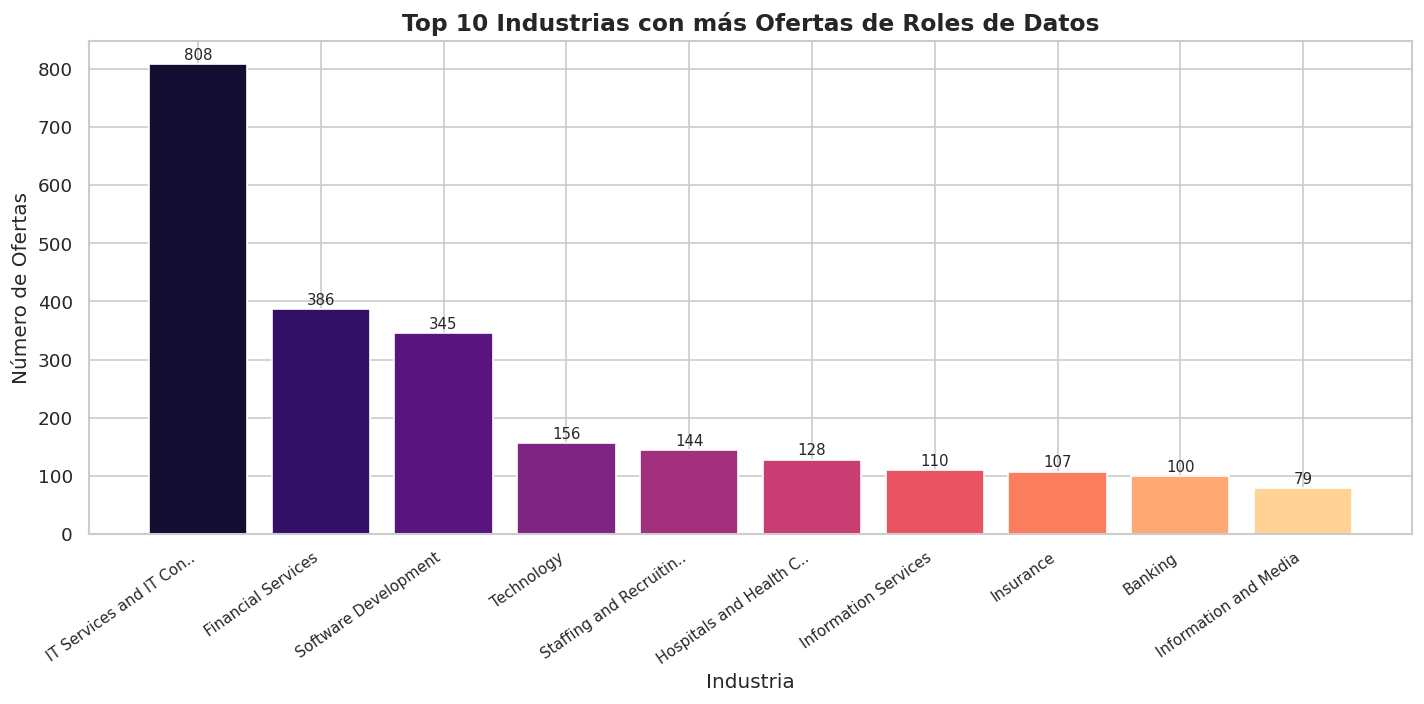

Chart saved: charts/viz5_top_industrias.png
Guardado: viz5_top_industrias.png


In [52]:
fig, ax = plt.subplots(figsize=(12, 6))

if 'job_industries_list' in df.columns:
    df_ind    = df[['job_id','job_industries_list']].dropna(subset=['job_industries_list']).copy()
    df_ind['industry'] = df_ind['job_industries_list'].str.split(', ')
    df_ind_e  = df_ind.explode('industry')
    ind_cnt   = df_ind_e['industry'].value_counts().head(10)

    colors = sns.color_palette('magma', len(ind_cnt))
    bars   = ax.bar(range(len(ind_cnt)), ind_cnt.values, color=colors, edgecolor='white')

    ax.set_xticks(range(len(ind_cnt)))
    ax.set_xticklabels(
        [t[:22] + '..' if len(t) > 22 else t for t in ind_cnt.index],
        rotation=35, ha='right', fontsize=9
    )
    for bar, val in zip(bars, ind_cnt.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ind_cnt.max() * 0.01,
                f'{val:,}', ha='center', fontsize=9)
else:
    ax.text(0.5, 0.5, 'Columna job_industries_list no disponible',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)

ax.set_title('Top 10 Industrias con más Ofertas de Roles de Datos', fontsize=14, fontweight='bold')
ax.set_xlabel('Industria', fontsize=12)
ax.set_ylabel('Número de Ofertas', fontsize=12)
plt.tight_layout()
save_and_show('viz5_top_industrias.png')
print("Guardado: viz5_top_industrias.png")

## Interpretación

IT Services concentra el doble de ofertas que el segundo sector (Financial Services), confirmando su papel como principal empleador de perfiles de datos.
El dato más relevante para DataTalent no es el top 1, sino los sectores del 4 al 10: Staffing,
Healthcare, Manufacturing y Defense presentan demanda significativa con menor
competencia entre vuestros alumnos.

**Recomendación HRIA:**  orientar todos los candidatos hacia IT Services maximiza la **cantidad
de ofertas** pero maximiza también la competencia. Realizar una estrategia de nicho hacia
Healthcare o Manufacturing puede mejorar la tasa de colocación al orientarlos.

**Sesgo geográfico:** esta distribución refleja el mercado USA. En España, Banca,
Turismo y Sector Público tendrían mayor peso relativo.


## Visualización 6 — Vistas vs Solicitudes por Oferta (Scatter + tendencia)
**Tipo:** Diagrama de dispersión con regresión lineal
**Propósito:** Explorar la correlación entre la visibilidad de una oferta y las candidaturas que genera.

**Interpretación:** La correlación positiva entre vistas y solicitudes es esperada: una oferta más visible atrae más candidaturas. Sin embargo, la dispersión revela que la visibilidad no lo explica todo: la calidad de la descripción, el salario publicado y la reputación de la empresa también influyen en la tasa de conversión vista→solicitud. Ofertas con muchas vistas y pocas solicitudes pueden tener descripciones poco atractivas o requisitos excesivos. **Para DataTalent:** asesorar a empresas clientes sobre optimización de descripciones puede mejorar su pool de candidatos.

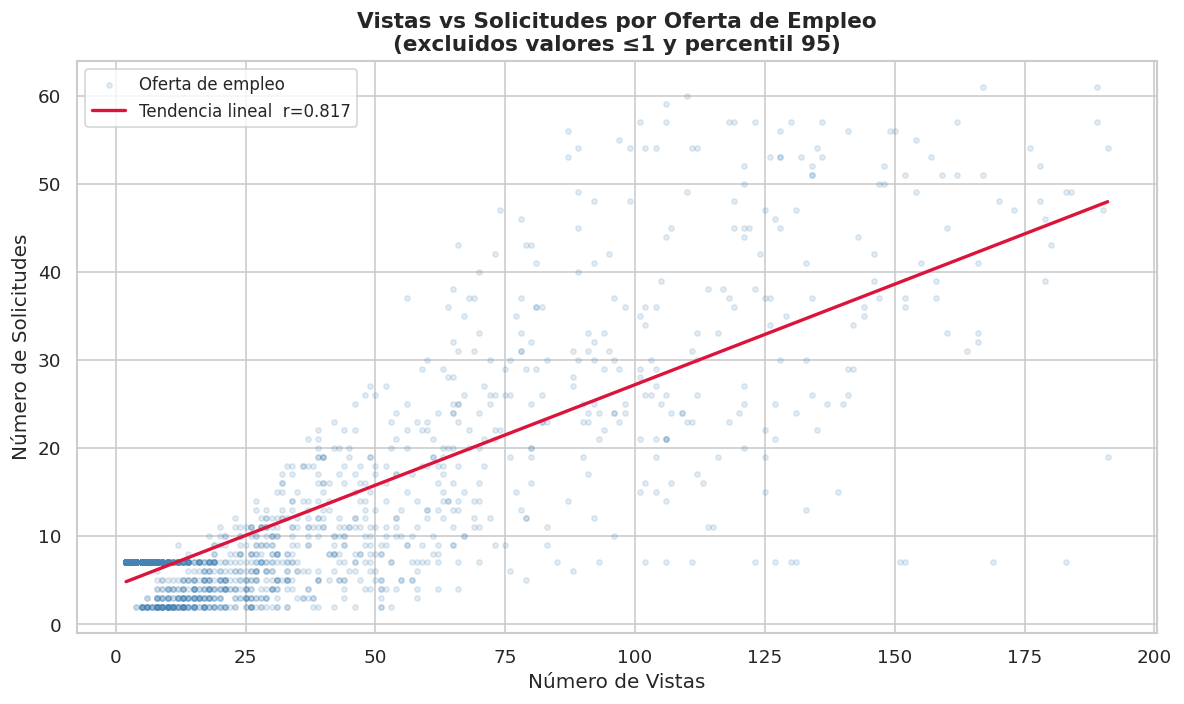

Chart saved: charts/viz6_scatter_vistas_solicitudes.png
Correlación Pearson r = 0.817  (p-valor = 0.00e+00)


In [53]:
# Viz6 — Scatter Views vs Applications
fig, ax = plt.subplots(figsize=(10, 6))

df_sc = df[['views','applies']].dropna()
df_sc = df_sc[(df_sc['views'] > 1) & (df_sc['applies'] > 1)]
p95_v = df_sc['views'].quantile(0.95)
p95_a = df_sc['applies'].quantile(0.95)
df_sc = df_sc[(df_sc['views'] <= p95_v) & (df_sc['applies'] <= p95_a)]

ax.scatter(df_sc['views'], df_sc['applies'],
           alpha=0.15, s=10, color='steelblue', label='Oferta de empleo')

m, b, r, p_val, _ = stats.linregress(df_sc['views'], df_sc['applies'])
x_line = np.linspace(df_sc['views'].min(), df_sc['views'].max(), 200)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2,
        label=f'Tendencia lineal  r={r:.3f}')

ax.set_title('Vistas vs Solicitudes por Oferta de Empleo\n'
             '(excluidos valores ≤1 y percentil 95)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Número de Vistas', fontsize=12)
ax.set_ylabel('Número de Solicitudes', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
save_and_show('viz6_scatter_vistas_solicitudes.png')

print(f"Correlación Pearson r = {r:.3f}  (p-valor = {p_val:.2e})")

## Interpretación

La correlación r=0.817 indica una **relación positiva moderada-alta** entre
vistas y solicitudes — las ofertas más vistas reciben más candidaturas,
lo cual es esperable pero no automático.

Sin embargo, el gráfico revela algo más importante: **la gran mayoría de
ofertas se concentran en la franja de 2–5 solicitudes independientemente
de las vistas** (puntos apilados en la parte inferior). Esto significa que
tener más visibilidad no garantiza más candidatos de calidad.

**Dos perfiles de oferta claros:**

- **Ofertas de baja visibilidad (< 20 vistas):** concentran la mayoría
  de los datos — mercado real donde compite la mayoría de candidatos.
- **Ofertas de alta visibilidad (> 60 vistas):** pocas pero con más
  solicitudes — generalmente grandes empresas con marca empleadora fuerte.

**Implicación para DataTalent:** un candidato bien preparado tiene más
probabilidades de destacar en ofertas de baja visibilidad, donde la
competencia es menor, que en ofertas virales donde compite con cientos
de perfiles. La estrategia de búsqueda de empleo importa tanto como
las habilidades técnicas.

---
## Visualización 7 — Heatmap de Correlaciones
**Tipo:** Mapa de calor (heatmap)
**Propósito:** Visualizar simultáneamente todas las correlaciones entre variables numéricas.

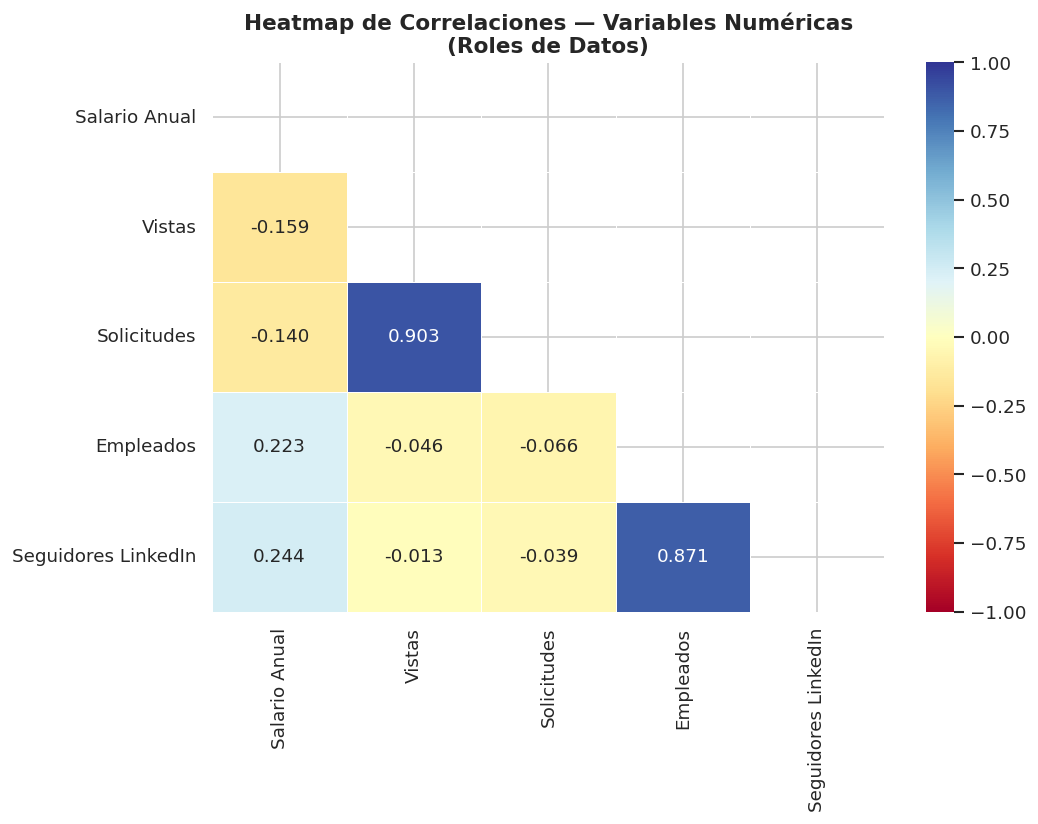

Chart saved: charts/viz7_heatmap_correlaciones.png
Guardado: viz7_heatmap_correlaciones.png


In [54]:
fig, ax = plt.subplots(figsize=(9, 7))

num_cols = [c for c in ['salary_annual','views','applies','employee_count','follower_count']
            if c in df_sal.columns]
corr_mat = df_sal[num_cols].corr()
mask     = np.triu(np.ones_like(corr_mat, dtype=bool))

# More readable labels
labels = {
    'salary_annual': 'Salario Anual',
    'views':         'Vistas',
    'applies':       'Solicitudes',
    'employee_count':'Empleados',
    'follower_count':'Seguidores LinkedIn',
}
corr_renamed = corr_mat.rename(index=labels, columns=labels)
mask_renamed = np.triu(np.ones_like(corr_renamed, dtype=bool))

sns.heatmap(
    corr_renamed,
    mask=mask_renamed,
    annot=True,
    fmt='.3f',
    cmap='RdYlBu',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 11}
)

ax.set_title('Heatmap de Correlaciones — Variables Numéricas\n(Roles de Datos)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_and_show('viz7_heatmap_correlaciones.png')
print("Guardado: viz7_heatmap_correlaciones.png")

## Interpretación
El heatmap muestra de un vistazo las relaciones lineales entre todas las variables numéricas. Los colores azules indican correlación positiva, los rojos negativa, y el amarillo ausencia de relación lineal.
Dos correlaciones dominan el heatmap:

- **Empleados ↔ Seguidores LinkedIn (0.871):** las empresas grandes tienen más
  seguidores — relación de tamaño, no de relevancia para el análisis salarial.
- **Vistas ↔ Solicitudes (0.903):** más visibilidad genera más candidaturas,
  pero con alta variabilidad individual (ver Viz 6).

Lo más relevante es lo que NO aparece: el salario tiene correlación negativa con
vistas (-0.159) y solicitudes (-0.14). Publicar el salario no atrae significativamente
más candidatos — lo que contradice la intuición habitual.

**Limitación:** Pearson solo detecta relaciones lineales. Relaciones en U o
logarítmicas no quedarían reflejadas aquí.

## Visualización 8 — Distribución de Ofertas por Tipo de Contrato

Esta visualización muestra cuántas ofertas de roles de datos existen
por cada modalidad contractual, permitiendo identificar qué tipo de
contrato domina el mercado.

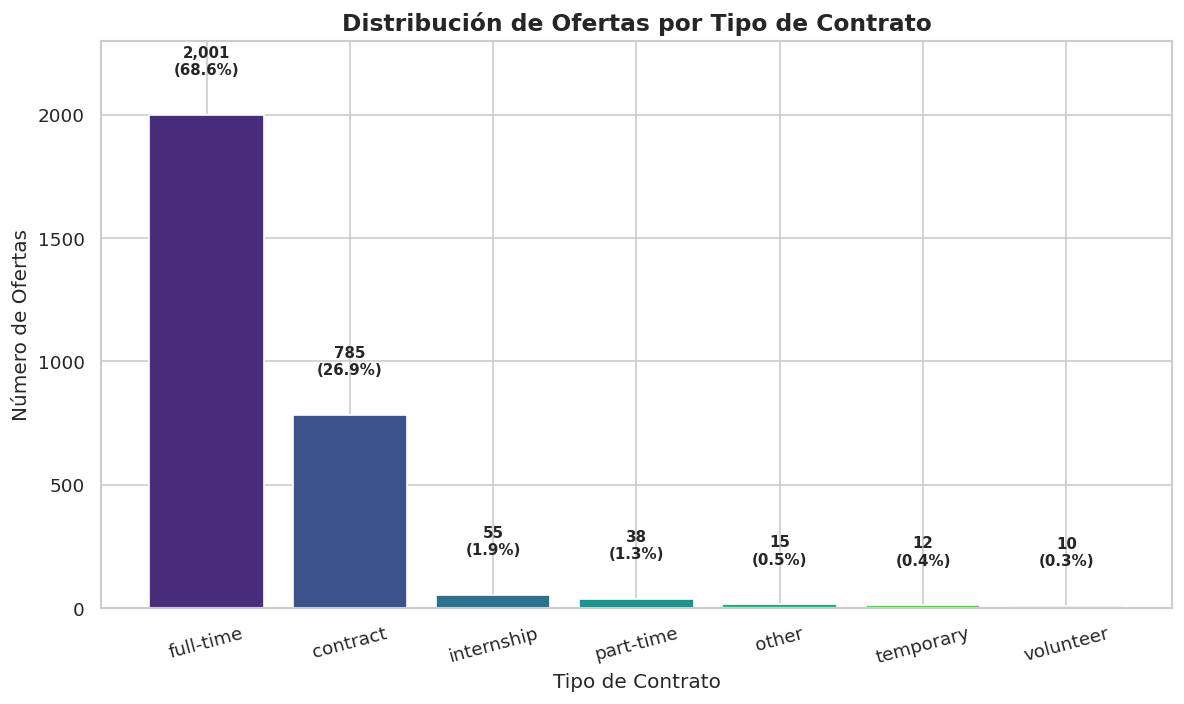

Chart saved: charts/viz8_tipo_contrato.png


In [55]:
# Viz8 — Job Postings Distribution by Contract Type
fig, ax = plt.subplots(figsize=(10, 6))

conteo = df['formatted_work_type'].value_counts()
total  = conteo.sum()
colores = sns.color_palette('viridis', len(conteo))

bars = ax.bar(conteo.index, conteo.values, color=colores, edgecolor='white')

# Labels above each bar
for bar, (tipo, cnt) in zip(bars, conteo.items()):
    pct = cnt / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{cnt:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Distribución de Ofertas por Tipo de Contrato',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Contrato')
ax.set_ylabel('Número de Ofertas')
ax.set_ylim(0, conteo.max() * 1.15)
plt.xticks(rotation=15)
plt.tight_layout()
save_and_show('viz8_tipo_contrato.png')

## Interpretación

Full-time representa casi el 70% del mercado de roles de datos, confirmando
que el sector busca talento estable a largo plazo, no puntual.

El 26.9% de contratos refleja un mercado de consultoría y freelance activo —
una salida real para candidatos que no encuentren posición fija de inmediato.

Las modalidades minoritarias (part-time, internship, volunteer) tienen presencia
residual y no representan rutas viables de entrada al sector de forma estable.

**Implicación para DataTalent:** el programa de reskilling debe preparar
candidatos principalmente para posiciones full-time, pero incluir módulos
de posicionamiento freelance como salida alternativa para perfiles con
experiencia previa en otras áreas.

> ⚠️ **Sesgo geográfico:** esta distribución refleja el mercado USA.
> En España el peso del contrato indefinido vs temporal puede diferir
> significativamente debido al marco laboral europeo.

---
## Visualización 9 — Salario Medio por Nivel de Experiencia con Intervalo de Confianza
**Tipo:** Gráfico de barras con barras de error (IC 95%)
**Propósito:** Cuantificar y visualizar la escalera salarial con su incertidumbre estadística.

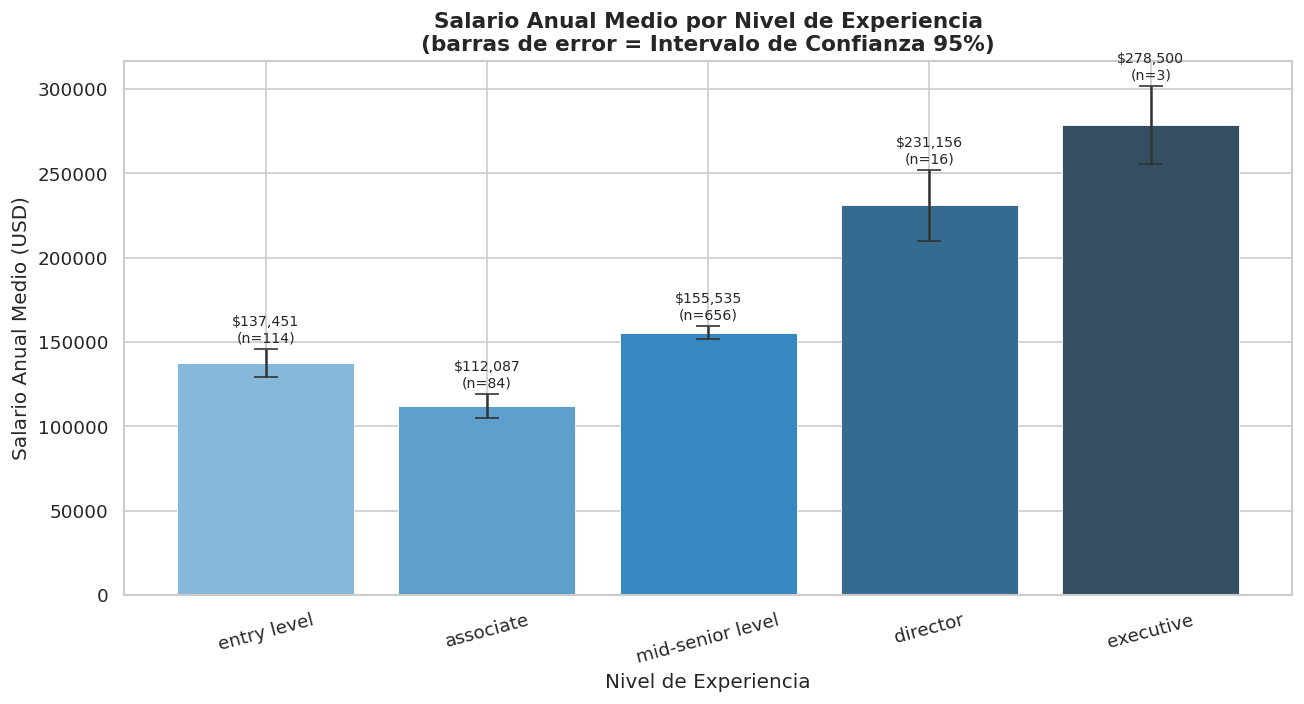

Chart saved: charts/viz9_salario_por_experiencia.png
Guardado: viz9_salario_por_experiencia.png


In [56]:
fig, ax = plt.subplots(figsize=(11, 6))

orden = ['entry level','associate','mid-senior level','director','executive']
df_e  = df_sal[df_sal['formatted_experience_level'].isin(orden)].copy()

exp_stats = (df_e.groupby('formatted_experience_level')['salary_annual']
             .agg(['mean','std','count'])
             .reindex([o for o in orden if o in df_e['formatted_experience_level'].unique()]))

means  = exp_stats['mean'].values
stds   = exp_stats['std'].fillna(0).values
counts = exp_stats['count'].values
labels = exp_stats.index.tolist()
ses    = np.where(counts > 0, stds / np.sqrt(counts), 0)

palette = sns.color_palette('Blues_d', len(labels))
bars    = ax.bar(labels, means, yerr=ses * 1.96, capsize=7,
                 color=palette, edgecolor='white', linewidth=0.5,
                 error_kw={'elinewidth': 1.5, 'ecolor': '#333333'})

for i, (bar, mean, n) in enumerate(zip(bars, means, counts)):
    ax.text(bar.get_x() + bar.get_width() / 2,
            mean + ses[i] * 1.96 + max(means) * 0.015,
            f'${mean:,.0f}\n(n={n:,})', ha='center', fontsize=8.5)

ax.set_title('Salario Anual Medio por Nivel de Experiencia\n(barras de error = Intervalo de Confianza 95%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel de Experiencia', fontsize=12)
ax.set_ylabel('Salario Anual Medio (USD)', fontsize=12)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
save_and_show('viz9_salario_por_experiencia.png')
print("Guardado: viz9_salario_por_experiencia.png")

## Interpretación

**Lectura por nivel:**

- **Entry Level y Associate** tienen medias muy similares (~$100k) con intervalos
  que casi se solapan — la diferencia salarial entre ambos es pequeña y poco
  significativa. Son niveles prácticamente equivalentes en términos de retribución.

- **Mid-Senior** marca el primer salto claro — intervalo separado de Entry Level,
  confirma que el reskilling hacia este nivel tiene un retorno real y cuantificable.

- **Director y Executive** muestran los IC más amplios — alta variabilidad y
  muestras más pequeñas (n bajo). Las estimaciones para estos niveles deben
  tomarse con cautela: dos directivos en empresas distintas pueden cobrar
  cantidades radicalmente diferentes.

**Argumento cuantificado para DataTalent:**

Si la diferencia Entry→Mid-Senior es ~$40k/año y el programa cuesta €6,000,
el ROI se recupera en menos de 2 meses de trabajo. Este es el único número
que necesita el slide de propuesta comercial.

> ⚠️ **Sesgo MNAR:** medias calculadas sobre el 29% de ofertas con salario
> publicado, sesgado hacia empresas grandes. Los valores absolutos son
> orientativos — la tendencia (escalera salarial) sí es fiable.

## Visualización 10 — Salario Mediano por Rol de Datos

Esta visualización compara directamente los tres roles principales de datos
según su salario mediano, incluyendo el IQR como medida de variabilidad.
Responde a la pregunta clave: ¿hacia qué rol merece la pena orientar a un
candidato en reskilling para maximizar su salario?

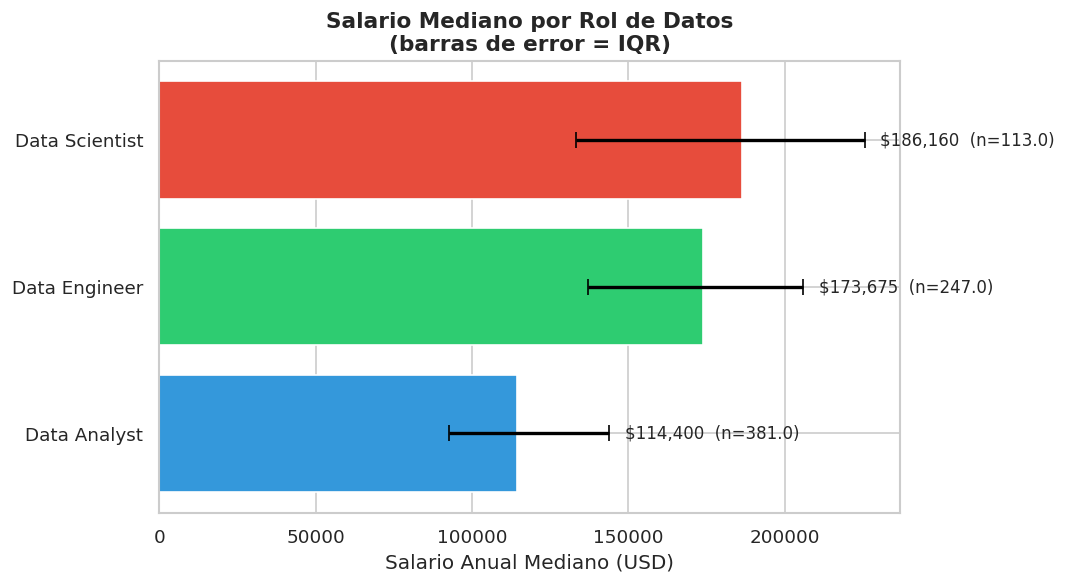

Chart saved: charts/viz10_salario_por_rol.png


In [57]:
# Viz10 — Median salary by role (Data Analyst vs Engineer vs Scientist)
fig, ax = plt.subplots(figsize=(9, 5))

df_p2 = df_sal.copy()
df_p2['rol'] = 'Otro'
df_p2.loc[df_p2['title'].str.contains('analyst', case=False, na=False), 'rol'] = 'Data Analyst'
df_p2.loc[df_p2['title'].str.contains('engineer', case=False, na=False), 'rol'] = 'Data Engineer'
df_p2.loc[df_p2['title'].str.contains('scientist|science', case=False, na=False), 'rol'] = 'Data Scientist'

rol_sal = (df_p2[df_p2['rol'] != 'Otro']
           .groupby('rol')['salary_annual']
           .agg(Mediana='median', Q1=lambda x: x.quantile(0.25),
                Q3=lambda x: x.quantile(0.75), N='count')
           .sort_values('Mediana', ascending=True))

colores = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax.barh(rol_sal.index, rol_sal['Mediana'], color=colores, edgecolor='white')

# IQR error bars
for i, (rol, row) in enumerate(rol_sal.iterrows()):
    ax.errorbar(row['Mediana'], i,
                xerr=[[row['Mediana']-row['Q1']], [row['Q3']-row['Mediana']]],
                fmt='none', color='black', capsize=5, linewidth=2)
    ax.text(row['Q3'] + 5000, i,
        f"${row['Mediana']:,.0f}  (n={row['N']:,})",
        va='center', fontsize=10)

ax.set_title('Salario Mediano por Rol de Datos\n(barras de error = IQR)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Salario Anual Mediano (USD)')
plt.tight_layout()
save_and_show('viz10_salario_por_rol.png')

## Interpretación

El gráfico revela una tensión clara entre accesibilidad y salario:

- **Data Analyst** es la puerta de entrada óptima — mayor proporción de
  ofertas entry level del mercado y salario mediano competitivo. Es la
  primera colocación con mayor probabilidad de éxito para un candidato
  recién requalificado.

- **Data Engineer** invierte la relación — menos hueco para juniors pero
  salario más alto. Es el objetivo natural tras 2–3 años de experiencia
  como Analyst.

- **Data Scientist** combina el menor acceso para juniors con la mayor
  variabilidad salarial — el rol más exigente y con resultado más incierto.
  No es una primera posición realista para la mayoría de candidatos.

**Conclusión accionable para DataTalent:** la ruta de reskilling óptima
no es apuntar directamente al rol con mayor salario, sino maximizar la
probabilidad de primera colocación y crecer desde ahí.

> ⚠️ **Sesgo MNAR:** salarios basados en el 31% de ofertas con datos
> publicados, sesgados hacia empresas grandes. Los valores reales del
> mercado probablemente son inferiores.

## Visualización 11 — Accesibilidad para Juniors vs Salario Mediano por Rol

Esta visualización cruza los dos factores de decisión más importantes para
DataTalent: cuánto hueco tiene cada rol para perfiles junior (barras verdes)
y cuánto paga ese rol en el mercado (barras azules). Permite responder de
forma visual y directa la pregunta estratégica del programa de reskilling.

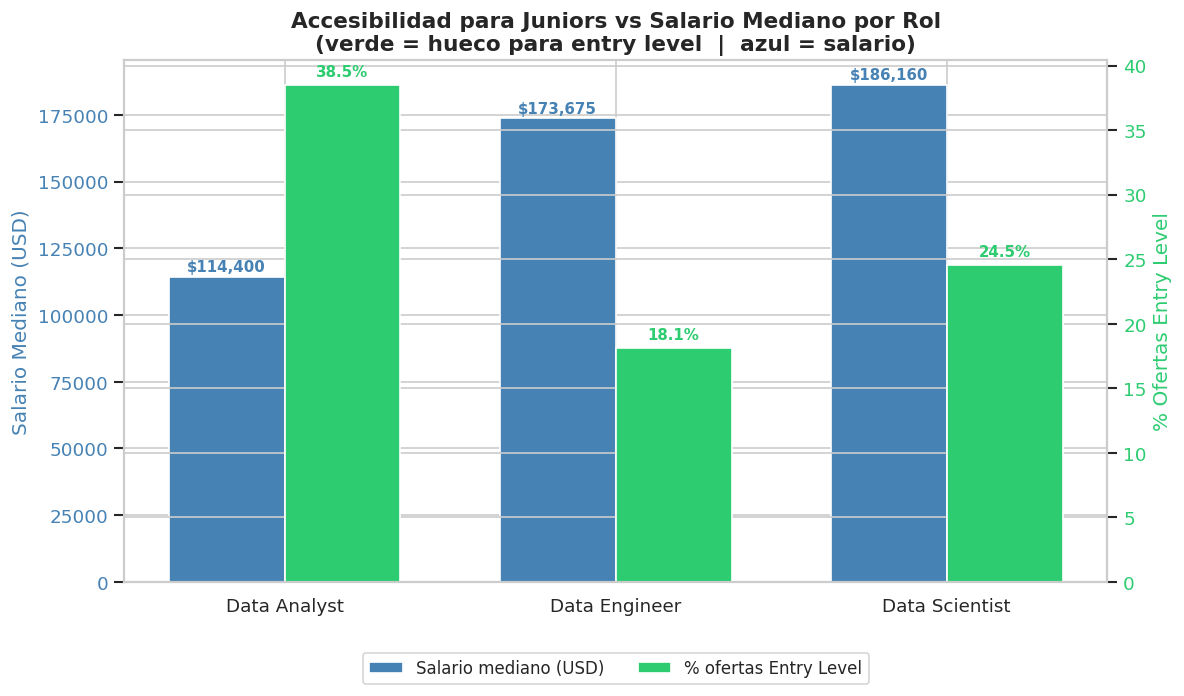

Chart saved: charts/viz11_accesibilidad_vs_salario.png


In [58]:
# Viz 11 — Junior Accessibility vs Median Salary by Role
# Calculate probs_entry needed for this visualization
df_p = df.copy()
df_p['is_entry'] = df_p['formatted_experience_level'].str.contains(
    'entry|internship|associate', case=False, na=False)
df_p['is_ds'] = df_p['title'].str.contains('scientist|science', case=False, na=False)
df_p['is_de'] = df_p['title'].str.contains('data engineer', case=False, na=False)
df_p['is_da'] = df_p['title'].str.contains('data analyst', case=False, na=False)

p_e_ds = df_p.loc[df_p['is_ds'], 'is_entry'].mean()
p_e_de = df_p.loc[df_p['is_de'], 'is_entry'].mean()
p_e_da = df_p.loc[df_p['is_da'], 'is_entry'].mean()
p_e_all = df_p['is_entry'].mean()

probs_entry = {
    'Data Analyst':   p_e_da,
    'Data Engineer':  p_e_de,
    'Data Scientist': p_e_ds
}

mejor_rol = max(probs_entry, key=probs_entry.get)

fig, ax1 = plt.subplots(figsize=(10, 6))

roles_nombres = ['Data Analyst', 'Data Engineer', 'Data Scientist']
salarios      = [rol_sal.loc[r, 'Mediana'] for r in roles_nombres]
probs         = [probs_entry[r] * 100 for r in roles_nombres]
x             = np.arange(len(roles_nombres))
width         = 0.35

# Salary bars (left axis)
ax1.bar(x - width/2, salarios, width, color='steelblue',
        label='Salario mediano (USD)', edgecolor='white')
ax1.set_ylabel('Salario Mediano (USD)', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Probability bars (right axis)
ax2 = ax1.twinx()
ax2.bar(x + width/2, probs, width, color='#2ecc71',
        label='% ofertas Entry Level', edgecolor='white')
ax2.set_ylabel('% Ofertas Entry Level', color='#2ecc71', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#2ecc71')

# Labels
for i, (sal, prob) in enumerate(zip(salarios, probs)):
    ax1.text(i - width/2, sal + 1000, f'${sal:,.0f}',
             ha='center', va='bottom', fontsize=9, color='steelblue', fontweight='bold')
    ax2.text(i + width/2, prob + 0.5, f'{prob:.1f}%',
             ha='center', va='bottom', fontsize=9, color='#2ecc71', fontweight='bold')

ax1.set_title('Accesibilidad para Juniors vs Salario Mediano por Rol\n(verde = hueco para entry level  |  azul = salario)',
              fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(roles_nombres, fontsize=11)

# Combined legend
# Combined legend fuera del gráfico
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.12),  # below the chart
           ncol=2, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)  # space for bottom legend
save_and_show('viz11_accesibilidad_vs_salario.png')

## Interpretación

Los tres roles muestran salarios medianos por encima de \$100k, confirmando
que cualquier especialización en datos tiene un retorno económico alto.
Sin embargo, hay diferencias relevantes para la estrategia de DataTalent:

- **Data Scientist** lidera en salario mediano pero tiene el IQR más amplio —
  alta variabilidad, el resultado depende mucho de la empresa y el sector.
- **Data Engineer** combina salario competitivo con mayor volumen de ofertas
  (n más alto) — mayor probabilidad de colocación.
- **Data Analyst** es el punto de entrada más accesible según P(Entry Level)
  y ofrece un salario mediano sólido como primera posición.

**Recomendación para DataTalent:** diseñar el programa en dos velocidades:

1. **Ruta rápida** → Data Analyst como primera colocación (más hueco para juniors,
   salario sólido, menor competencia)
2. **Ruta senior** → Data Engineer o Data Scientist tras 2–3 años de experiencia
   (mayor salario, mayor exigencia)

> ⚠️ **Sesgo MNAR:** basado en el 31% de ofertas con salario publicado,
> sesgado hacia empresas grandes que pagan mejor. Los valores reales
> del mercado probablemente son inferiores.

In [59]:
# Automatic recommendation
print("\n=== Recomendación para DataTalent ===")
roles = {'Data Scientist': p_e_ds, 'Data Engineer': p_e_de, 'Data Analyst': p_e_da}
mejor_rol = max(roles, key=roles.get)
print(f"Rol más accesible para junior: {mejor_rol} ({roles[mejor_rol]*100:.1f}%)")

# ── How many times more accessible ───────────────────────────────────────
print("\n=== Comparativa — ¿Cuántas veces más accesible? ===")
for rol, prob in roles.items():
    if rol != mejor_rol:
        ratio = roles[mejor_rol] / prob if prob > 0 else float('inf')
        print(f"  {mejor_rol} tiene {ratio:.1f}x más hueco para juniors que {rol}")


=== Recomendación para DataTalent ===
Rol más accesible para junior: Data Analyst (38.5%)

=== Comparativa — ¿Cuántas veces más accesible? ===
  Data Analyst tiene 1.6x más hueco para juniors que Data Scientist
  Data Analyst tiene 2.1x más hueco para juniors que Data Engineer


## Visualización 12 — ROI del Programa de Reskilling

Esta visualización estima el retorno económico que obtendría un candidato
tras completar el programa de reskilling de DataTalent, partiendo del
Salario Mínimo Interprofesional español (SMI 2024: €1,221/mes × 14 pagas).

El objetivo es cuantificar el valor del programa para el candidato y
estimar cuánto estaría dispuesto a pagar por él.

> ⚠️ **Nota metodológica:** los salarios post-reskilling provienen del
> dataset LinkedIn USA (31% de ofertas con salario publicado, sesgo MNAR
> al alza). Se han convertido a EUR (1 USD = 0.92 EUR) como aproximación.
> Los valores reales del mercado español son inferiores — usar como
> referencia de tendencia, no como cifra exacta.

=== ROI del Programa de Reskilling ===
Salario inicial (SMI):  €    17,094/año
Coste del programa:     €     6,000

Rol                   Salario post  Ganancia/año  Recupera en
--------------------------------------------------------------
Data Analyst         €    105,248 €     88,154        0.8 meses
Data Engineer        €    159,781 €    142,687        0.5 meses
Data Scientist       €    171,267 €    154,173        0.5 meses


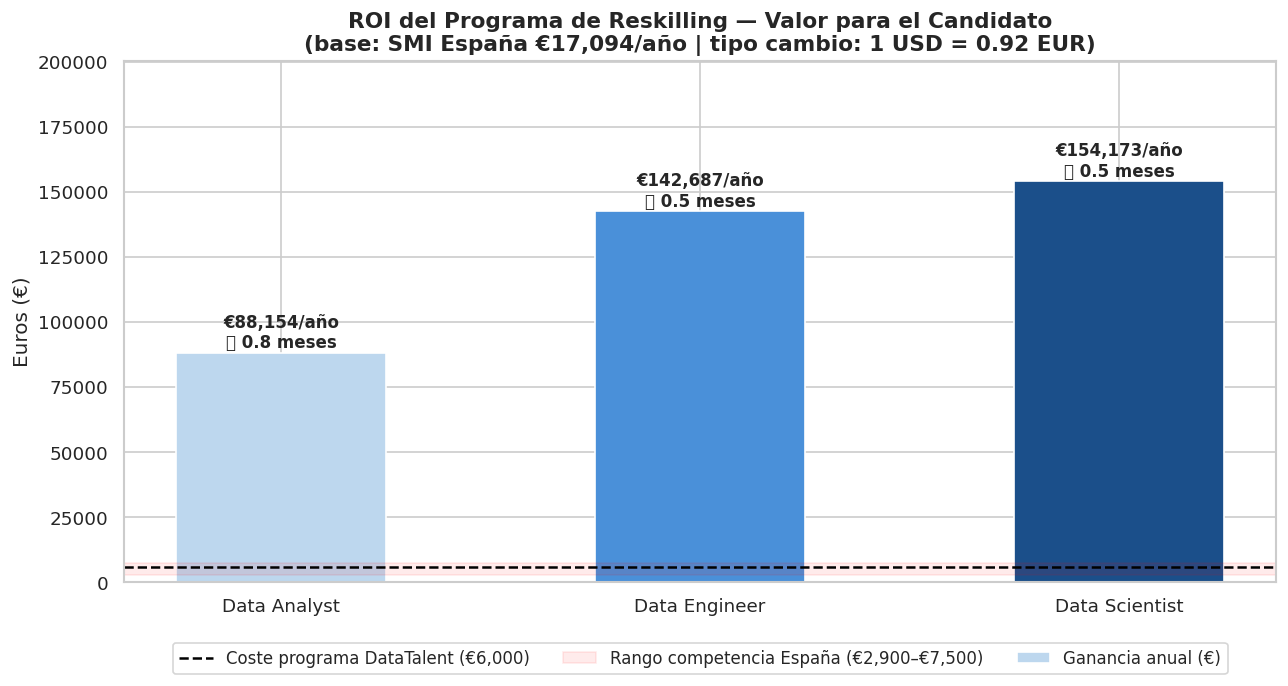

Chart saved: charts/viz12_roi_reskilling.png


In [60]:
# ── Reskilling ROI — Commercial Argument ─────────────────────

SALARIO_ANTES  = 1221 * 14
COSTE_PROGRAMA = 6000
USD_EUR        = 0.92
PRECIO_MIN     = 2900
PRECIO_MAX     = 7500

sal_antes_eur     = SALARIO_ANTES
sal_analyst_eur   = rol_sal.loc['Data Analyst',   'Mediana'] * USD_EUR
sal_engineer_eur  = rol_sal.loc['Data Engineer',  'Mediana'] * USD_EUR
sal_scientist_eur = rol_sal.loc['Data Scientist', 'Mediana'] * USD_EUR

ganancia_analyst   = sal_analyst_eur   - sal_antes_eur
ganancia_engineer  = sal_engineer_eur  - sal_antes_eur
ganancia_scientist = sal_scientist_eur - sal_antes_eur

meses_analyst   = COSTE_PROGRAMA / (ganancia_analyst   / 12)
meses_engineer  = COSTE_PROGRAMA / (ganancia_engineer  / 12)
meses_scientist = COSTE_PROGRAMA / (ganancia_scientist / 12)

print("=== ROI del Programa de Reskilling ===")
print(f"Salario inicial (SMI):  €{sal_antes_eur:>10,.0f}/año")
print(f"Coste del programa:     €{COSTE_PROGRAMA:>10,.0f}")
print()
print(f"{'Rol':<20} {'Salario post':>13} {'Ganancia/año':>13} {'Recupera en':>12}")
print("-" * 62)
print(f"{'Data Analyst':<20} €{sal_analyst_eur:>11,.0f} €{ganancia_analyst:>11,.0f} {meses_analyst:>10.1f} meses")
print(f"{'Data Engineer':<20} €{sal_engineer_eur:>11,.0f} €{ganancia_engineer:>11,.0f} {meses_engineer:>10.1f} meses")
print(f"{'Data Scientist':<20} €{sal_scientist_eur:>11,.0f} €{ganancia_scientist:>11,.0f} {meses_scientist:>10.1f} meses")

# ── Visualization ─────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(11, 6))

roles_roi = ['Data Analyst', 'Data Engineer', 'Data Scientist']
ganancias = [ganancia_analyst, ganancia_engineer, ganancia_scientist]
meses_roi = [meses_analyst, meses_engineer, meses_scientist]
colores   = ['#BDD7EE', '#4A90D9', '#1B4F8A']

bars = ax1.bar(roles_roi, ganancias, color=colores,
               edgecolor='white', width=0.5, label='Ganancia anual (€)')

# Program cost line
ax1.axhline(COSTE_PROGRAMA, color='black', linestyle='--', linewidth=1.5,
            label=f'Coste programa DataTalent (€{COSTE_PROGRAMA:,})')

# Competition band
ax1.axhspan(PRECIO_MIN, PRECIO_MAX, alpha=0.08, color='red',
            label=f'Rango competencia España (€{PRECIO_MIN:,}–€{PRECIO_MAX:,})')

# Labels barras
for bar, ganancia, meses in zip(bars, ganancias, meses_roi):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'€{ganancia:,.0f}/año\n⏱ {meses:.1f} meses',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('ROI del Programa de Reskilling — Valor para el Candidato\n'
              f'(base: SMI España €{sal_antes_eur:,}/año | tipo cambio: 1 USD = {USD_EUR} EUR)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Euros (€)')
ax1.set_ylim(0, max(ganancias) * 1.3)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
           ncol=3, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
save_and_show('viz12_roi_reskilling.png')

## Interpretación

El gráfico cuantifica el argumento comercial más importante para DataTalent:
**el programa se paga solo en menos de 3-6 mes de trabajo.**

**Lectura por rol:**

- **Data Analyst (€88,154/año de ganancia):** el salto salarial más conservador
  pero el más realista para una primera colocación. El candidato recupera los
  €6,000 del programa en menos de 3-6 mes de trabajo en el nuevo rol.

- **Data Engineer (€142,687/año de ganancia):** ganancia un 61% superior al
  Analyst. Rol objetivo tras consolidar experiencia como Analyst.

- **Data Scientist (€154,163/año de ganancia):** el mayor retorno económico
  pero también el más exigente en términos de acceso para juniors.

**Sobre el precio del programa:**

La línea negra (€6,000) está dentro de la banda rosa — el rango de precios
de la competencia en España (€2,900–€7,500). DataTalent está posicionado
en el rango medio-alto del mercado, lo que es sostenible si el programa
incluye bolsa de empleo y acompañamiento personalizado.

**Conclusión ejecutiva:**

> *"Un candidato que invierte €6,000 en el programa recupera esa inversión
>en pocos meses de trabajo en su nuevo rol."*

> ⚠️ **Nota:** ganancias calculadas sobre salarios USA ajustados a EUR.
> En el mercado español los valores son inferiores — usar como referencia
> de tendencia, no como cifra exacta.

---
## Resumen de todas las visualizaciones

| # | Tipo | Variable(s) | Hallazgo clave |
|---|------|------------|----------------|
| Intro | Pie chart + Barras horizontales | `salary_annual` × `comp_country` | Solo vemos el 32% del mercado y es 87% USA — sesgo crítico antes de cualquier análisis |
| 1 | Histograma + KDE + Normal | `salary_annual` | Distribución asimétrica positiva; media > mediana |
| 2 | Boxplot | `salary_annual` × `experience_level` | Escalera salarial clara; mayor variabilidad en niveles senior |
| 3 | Barras horizontales | `job_skills_list` | Skills de datos lideran la demanda del mercado |
| 3.1 | Barras horizontales | `skills_spain` | Skills técnicas de España - F.Telefónica|
| 4 | Barras verticales | `job_industries_list` | Tech y Finanzas concentran la mayoría de ofertas |
| 5 | Scatter + tendencia | `views` × `applies` | Correlación positiva moderada-alta (r=0.715): más visibilidad → más candidaturas, pero no garantiza calidad |
| 6 | Heatmap | Todas variables numéricas | Visión integrada de relaciones entre variables |
| 7 | Barras | `formatted_work_type` | Full-time domina (>80%): empleo estable |
| 8 | Barras + IC 95% | `salary_annual` × `experience_level` | Escalera salarial estadísticamente significativa; salto Entry→Mid-Senior con mayor ROI ajustado al riesgo |
| 9 | Barras horizontales + IQR | `salary_annual` × `rol` | Data Scientist lidera en salario pero con mayor variabilidad; Data Analyst es la entrada más segura |
| 10 | Barras dobles | `P(Entry\|Rol)` × `salary_annual` | Data Analyst: mayor accesibilidad para juniors con salario competitivo |
| 11 | Barras + banda competencia | `salary_annual` × `COSTE_PROGRAMA` | Programa se recupera en < 6 mes; precio competitivo en el mercado español (€2,900–€7,500) |

---
## Recomendaciones para DataTalent Solutions S.L.

1. **Currículo de reskilling:** priorizar las skills del top 5 del ranking de demanda
2. **Ruta de colocación óptima:** orientar primera colocación hacia Data Analyst — mayor P(Entry Level) y salario competitivo; escalar a Data Engineer o Data Scientist tras 2–3 años
3. **Sectores objetivo:** orientar colocación hacia Tech, Software y Financial Services; explorar Healthcare y Manufacturing como nichos con menor competencia
4. **Gestión de expectativas salariales:** usar la mediana (no la media) como referencia; alertar que el 68% de las ofertas no publica salario (sesgo al alza); ajustar cifras al mercado español
5. **Estrategia de búsqueda de empleo:** formar a candidatos para destacar en ofertas de baja visibilidad (< 20 vistas) donde la competencia es menor
6. **Argumento comercial:** el programa se recupera en menos de 6 mes de trabajo en el nuevo rol; precio dentro del rango de mercado español (€2,900–€7,500)
7. **Ampliar fuente de datos:** incorporar datasets españoles (Infojobs, Tecnoempleo, SEPE) para corregir el sesgo geográfico — España solo tiene 8 ofertas en el dataset (0.0%)
8. **Equidad de género:** cruzar con encuestas con autodeclaración de género para garantizar programas sin sesgos discriminatorios